# Imports

In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import make_moons, make_circles, make_blobs

import math
import random
from dataclasses import dataclass, asdict
import json
from pathlib import Path
import re
import copy

import matplotlib.pyplot as plt

from typing import Optional, Union, Tuple, Literal, Callable, Dict

from contextlib import contextmanager


from datetime import datetime
from types import SimpleNamespace
from typing import Any, List


from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm

from decimal import Decimal

import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

from matplotlib.ticker import FormatStrFormatter

import matplotlib as mpl
import matplotlib.patheffects as pe
from matplotlib.patches import Ellipse
import colorsys

## Global Variables

In [2]:
ID_METHOD_NAME =   "ImpDiff"
SOSMC_METHOD_NAME = "SOSMC-ULA"

METHOD_COLORS = {
    f"{ID_METHOD_NAME}": "#003f5c",
    f"{SOSMC_METHOD_NAME}": "#bc5090",
}

## Config Schema

In [3]:
@dataclass
class ConfigDataset:
    name: Literal["two_moons", "circles", "blobs"]
    n_samples: int = 20000
    noise: float = 0.08
    scale: float = 2.2
    seed: int = 0

    # Circles-specific
    circles_factor: float = 0.5

    # Blobs-specific
    blobs_n_centers: int = 4
    blobs_cluster_std: float = 0.8


@dataclass
class ConfigModel:
    hidden_dim: int = 128
    depth: int = 3
    init_std: float = 0.02


@dataclass
class ConfigSampler:
    n_steps_train: int = 80
    n_steps_eval: int = 200
    step_size: float = 0.01
    noise_scale: float = 1.0
    clamp_value: Optional[float] = 6.0


@dataclass
class ConfigTraining:
    batch_size: int = 512
    epochs: int = 200
    lr: float = 2e-4

    # Replay buffer
    replay_size: int = 20000
    replay_reinit_prob: float = 0.05
    particle_init_lim: float = 4.5

    # Regularisation
    energy_decay: float = 1e-3
    grad_penalty_weight: float = 0.2
    grad_clip_norm: float = 10.0

    # Logging & Checkpointing
    plot_every: int = 25
    plot_n_samples: int = 5000
    save_every: int = 50
    log_every: int = 1

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 0


@dataclass
class ConfigExperiment:
    dataset: ConfigDataset
    model: ConfigModel
    sampler: ConfigSampler
    training: ConfigTraining

    # Output directory
    output_dir: str = "saved_models"
    experiment_name: str = "ebm_two_moons"

    def save(self, path: Path):
        """
        Save config to .json file.
        """
        with open(path, "w") as f:
            json.dump(asdict(self), f, indent=2)

    @classmethod
    def load(cls, path: Path):
        """
        Load config from .json file.
        """
        with open(path, "r") as f:
            data = json.load(f)

        return cls(
            dataset=ConfigDataset(**data["dataset"]),
            model=ConfigModel(**data["model"]),
            sampler=ConfigSampler(**data["sampler"]),
            training=ConfigTraining(**data["training"]),
            output_dir=data["output_dir"],
            experiment_name=data["experiment_name"],
        )
    

@dataclass
class ConfigIDRewardTuner:
    ### General ###
    # Particle system
    n_particles: int = 512
    particle_init_lim: float = 6.0
    particle_reinit_prob: float = 0.00

    # Implicit Diffusion outer loop
    n_outer_steps: int = 1000
    # One sampling steps per outer update (Algorithm 2)
    sampler_steps_per_outer: int = 1

    gamma: float = 5e-3
    noise_scale: float = 1.0

    # Optional clamping of particles
    clamp_value: Optional[float] = None

    # KL weight
    beta_kl: float = 1.0

    lr: float = 5e-6
    grad_clip_norm: float = 1000.0

    optimiser_alias: str = "adam"
    optimiser_kwargs: dict = None

    # Logging
    log_every: int = 50
    plot_every: int = 100
    plot_n_samples: int = 5000
    plot_langevin_steps: int = 3000

    # Evaluation
    n_eval_fresh: int = 200            # Evaluate every n_eval_fresh outer steps
    eval_n_samples: int = 5000         # Number of fresh samples
    eval_langevin_steps: int = 3000    # Length of eval chain
    eval_step_size: float = 5e-3
    eval_noise_scale: float = 1.0
    eval_clamp_value: float = None
    eval_thin: int = 1
    eval_burn_in: int = 300

    ### SOSMC Specific ###
    ess_resample_ratio: float = None
    ess_adapt_ratio: float = None
    gamma_min: float = None
    gamma_max: float = None
    adapt_factor: float = None


@dataclass
class ExperimentSweepConfig:
    base_config: Dict[str, Any]
    beta_kl_values: List[float]
    seeds: List[int]
    run_impdiff: bool = True
    run_sosmc: bool = True
    output_root: str = "reward_tuning_runs"
    experiment_name: str = "beta_sweep"

## Utility Functions

In [4]:
### Reproducibility ###

def set_seed(seed: int = 0):
    """
    Sets a variety of seeds for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


### Processing ###

def standardize_and_scale(X: np.ndarray, scale: float = 2.2) -> torch.Tensor:
    """
    Standardizes data to zero mean, unit variance, and then scales by `scale`.
    """
    X = X.astype(np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / (X.std(axis=0, keepdims=True) + 1e-8)
    X = X * scale

    return torch.from_numpy(X)


### Dataset Generation ###

def make_dataset_2d(config_dataset: ConfigDataset) -> torch.Tensor:
    """
    Generates a 2D dataset based on `config_dataset` passed.
    """
    name = config_dataset.name
    n = config_dataset.n_samples
    noise = config_dataset.noise
    scale = config_dataset.scale
    seed = config_dataset.seed

    if name == "two_moons":
        X, _ = make_moons(n_samples=n, noise=noise, random_state=seed)
        return standardize_and_scale(X, scale=scale)

    if name == "circles":
        X, _ = make_circles(
            n_samples=n,
            noise=noise,
            factor=config_dataset.circles_factor,
            random_state=seed,
        )
        return standardize_and_scale(X, scale=scale)

    if name == "blobs":
        X, _ = make_blobs(
            n_samples=n,
            centers=config_dataset.blobs_n_centers,
            cluster_std=config_dataset.blobs_cluster_std,
            random_state=seed,
        )
        return standardize_and_scale(X, scale=scale)

    raise ValueError(f"Unknown dataset name: {name}.\nTry: two_moons, circles, blobs")


### Rewards ###

def reward_right_halfplane(x: torch.Tensor) -> torch.Tensor:
    """
    Reward x > 0.
    """
    return (x[:, 0] > 0).float()


def reward_left_halfplane(x: torch.Tensor) -> torch.Tensor:
    """
    Reward x < 0.
    """
    return (x[:, 0] < 0).float()


def reward_upper_halfplane(x: torch.Tensor) -> torch.Tensor:
    """
    Reward y > 0.
    """
    return (x[:, 1] > 0).float()


def reward_lower_halfplane(x: torch.Tensor) -> torch.Tensor:
    """
    Reward y < 0.
    """
    return (x[:, 1] < 0).float()


def reward_zero(x: torch.Tensor) -> torch.Tensor:
    """
    Returns zero.
    """
    return torch.zeros_like(x[:, 0])


### Statistics ###

def pearson_corr_1d(a: torch.Tensor, b: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """
    Computes the Pearson correlation coefficient between two tensors. Returns nan if variance is ~0.
    """
    a = a.flatten()
    b = b.flatten()
    a = a - a.mean()
    b = b - b.mean()
    denom = (a.std(unbiased=False) * b.std(unbiased=False)).clamp_min(eps)
    
    return (a * b).mean() / denom


def first_hitting_times(traj: torch.Tensor, region_fn) -> np.ndarray:
    """
    Computes the first time upon which the `traj` enters the region defined by `region_fun`.
    """
    T1, N, _ = traj.shape
    hits = torch.full((N,), fill_value=T1, device=traj.device, dtype=torch.long)

    for t in range(T1):
        in_region = region_fn(traj[t]).bool()
        newly = in_region & (hits == T1)
        hits[newly] = t

    return hits.detach().cpu().numpy()

## Utility Functions - Langevin Dynamics

In [5]:
### Gaussian Langevin Sampler ###

def langevin_sample(
    energy_model: torch.nn.Module,
    x_init: torch.Tensor,
    n_steps: int,
    step_size: float,
    noise_scale: float,
    clamp_value: Optional[float] = None,
):
    """
    Gaussian Langevin sampler for p(x) \\propto exp(-E_{\theta}(x)), where we can specify a noise scale!
    """
    # Save & disable parameter grads (we only need grad wrt x)
    old_req = [p.requires_grad for p in energy_model.parameters()]
    for p in energy_model.parameters():
        p.requires_grad_(False)

    x = x_init.detach()

    with torch.enable_grad():
        for _ in range(n_steps):
            x.requires_grad_(True)

            e = energy_model(x).sum()
            grad_x = torch.autograd.grad(e, x, create_graph=False)[0]

            x = x.detach() - (step_size * grad_x.detach())
            x = x + ((2 * step_size) ** 0.5) * noise_scale * torch.randn_like(x)

            if clamp_value is not None:
                x = torch.clamp(x, -clamp_value, clamp_value)

    # Restore parameter grads
    for p, r in zip(energy_model.parameters(), old_req):
        p.requires_grad_(r)

    return x.detach()


def generate_langevin_samples_from_energy(
    *,
    energy_model,
    n_samples: int = 3000,
    n_steps: int,
    step_size: float,
    noise_scale: float,
    clamp_value: Optional[float] = None,
    particle_init_lim: float = 4.5,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
) -> torch.Tensor:
    """
    Generates samples from the model via Gaussian Langevin sampling.
    """
    energy_model.eval()

    with torch.no_grad():
        x0 = (torch.rand(n_samples, 2, device=device) * 2 - 1) * particle_init_lim

    x_samp = langevin_sample(
        energy_model=energy_model,
        x_init=x0,
        n_steps=n_steps,
        step_size=step_size,
        noise_scale=noise_scale,
        clamp_value=clamp_value,
    )

    energy_model.train()

    return x_samp


@torch.no_grad()
def make_particles(
    n: int,
    init_lim: float,
    device: str,
    seed: int = 0,
    *,
    mode: str = "uniform",
    margin: float = 0.0,
    band: float = 0.5,
    p_band: float = 0.0,
    band_side: str = "below",
    axis: str = "y",
) -> torch.Tensor:
    """
    Initialises particles according to the specified `mode`.
    """
    assert band > 0
    assert 0.0 <= p_band <= 1.0

    g = torch.Generator(device=device)
    g.manual_seed(seed)

    x = (torch.rand(n, 2, device=device, generator=g) * 2 - 1) * init_lim

    def apply_halfplane(xx: torch.Tensor, m: str):
        if m == "upper":
            xx[:, 1] = xx[:, 1].abs() + float(margin)
        elif m == "lower":
            xx[:, 1] = -xx[:, 1].abs() - float(margin)
        elif m == "right":
            xx[:, 0] = xx[:, 0].abs() + float(margin)
        elif m == "left":
            xx[:, 0] = -xx[:, 0].abs() - float(margin)
        return xx

    def apply_band(xx: torch.Tensor, ax: str, side: str):
        # Constrains coordinate to a band near 0
        if ax == "y":
            if side == "above":
                yy = torch.rand(xx.shape[0], device=device, generator=g) * float(band)
                xx[:, 1] = yy
            else:
                yy = -torch.rand(xx.shape[0], device=device, generator=g) * float(band)
                xx[:, 1] = yy
        else:
            if side == "above":
                xxv = torch.rand(xx.shape[0], device=device, generator=g) * float(band)
                xx[:, 0] = xxv
            else:
                xxv = -torch.rand(xx.shape[0], device=device, generator=g) * float(band)
                xx[:, 0] = xxv
        return xx

    if mode == "uniform":
        return x

    if mode in ("upper", "lower", "left", "right"):
        x = apply_halfplane(x, mode)
        x = torch.clamp(x, -init_lim, init_lim)
        return x

    if mode == "band_y":
        x = apply_band(x, "y", band_side)
        x = torch.clamp(x, -init_lim, init_lim)
        return x

    if mode == "band_x":
        x = apply_band(x, "x", band_side)
        x = torch.clamp(x, -init_lim, init_lim)
        return x

    if mode == "mixture":
        n_band = int(round(p_band * n))
        perm = torch.randperm(n, device=device, generator=g)
        idx_band = perm[:n_band]

        x_band = x[idx_band].clone()
        ax = "y" if axis == "y" else "x"
        x_band = apply_band(x_band, ax, band_side)

        x[idx_band] = x_band
        x = torch.clamp(x, -init_lim, init_lim)
        return x

    raise ValueError(f"Unknown mode: {mode}")

@torch.no_grad()
def make_shared_noise(n_steps: int, n_particles: int, dim: int, device: str, seed: int = 0) -> torch.Tensor:
    """
    Creates reproducible noise, across all `steps`, for `n_particles` particles.
    """
    g = torch.Generator(device=device)
    g.manual_seed(seed)
    eps = torch.randn(n_steps, n_particles, dim, device=device, generator=g)
    
    return eps


def langevin_trajectory(
    energy_model: torch.nn.Module,
    x_init: torch.Tensor,
    eps: torch.Tensor,
    step_size: float,
    noise_scale: float = 1.0,
    clamp_value=None,
) -> torch.Tensor:
    """
    Returns a trajectory tensor using:
    x_{t+1} = x_t - h gradE(x_t) + sqrt(2h)*noise_scale*eps[t]
    """
    old_req = [p.requires_grad for p in energy_model.parameters()]
    for p in energy_model.parameters():
        p.requires_grad_(False)

    x = x_init.detach()
    T = eps.shape[0]
    traj = [x.detach()]

    with torch.enable_grad():
        for t in range(T):
            x = x.detach().requires_grad_(True)
            e = energy_model(x).sum()
            grad_x = torch.autograd.grad(e, x, create_graph=False)[0]

            x_next = x.detach() - step_size * grad_x.detach()
            x_next = x_next + (2.0 * step_size) ** 0.5 * float(noise_scale) * eps[t]

            if clamp_value is not None:
                x_next = torch.clamp(x_next, -clamp_value, clamp_value)

            x = x_next
            traj.append(x.detach())

    for p, r in zip(energy_model.parameters(), old_req):
        p.requires_grad_(r)

    return torch.stack(traj, dim=0)

## Utility Functions - Plotting

In [6]:
def plot_2d_comparison(
    data: np.ndarray,
    samples: np.ndarray,
    title: str = "",
    lim: float = 6.0,
):
    """
    Plots data vs model samples side by side.
    """
    plt.figure(figsize=(6, 6))

    if data is not None:
        plt.scatter(data[:, 0], data[:, 1], s=5, alpha=0.35, label="data", c="blue")

    if samples is not None:
        plt.scatter(
            samples[:, 0], samples[:, 1], s=5, alpha=0.35, label="model", c="red"
        )

    plt.legend()
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.title(title)

    plt.tight_layout()

    plt.show()


### Gaussian Langevin Sampler ###

@torch.no_grad()
def visualise_langevin_samples(
    *,
    energy_model,
    plot_n_samples: int = 3000,
    n_steps: int,
    step_size: float,
    noise_scale: float,
    clamp_value: Optional[float] = None,
    particle_init_lim: float = 4.5,
    device: str = "cuda" if torch.cuda.is_available() else "cpu",
    data_to_also_plot: Optional[torch.Tensor] = None,
    plot_lim: float = 6.0,
    title: str = "",
):
    """
    Visualises fresh samples drawn via the longer Langevin chain.
    """
    x_samp = generate_langevin_samples_from_energy(
        energy_model=energy_model,
        n_samples=plot_n_samples,
        n_steps=n_steps,
        step_size=step_size,
        noise_scale=noise_scale,
        clamp_value=clamp_value,
        particle_init_lim=particle_init_lim,
        device=device,
    )

    if data_to_also_plot is None:
        # Plot model samples if no cached data provided!
        data_np = None
        samples_np = x_samp.cpu().numpy()
    else:
        data_np = data_to_also_plot[:plot_n_samples].cpu().numpy()
        samples_np = x_samp.cpu().numpy()

    plot_2d_comparison(
        data=data_np,
        samples=samples_np,
        title=title,
        lim=plot_lim,
    )


### Plotting Utility Functions ###

def set_pub_style(font_size=11):
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size + 1,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size + 1,
        "axes.linewidth": 1.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })


def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=5, width=1.5)
    ax.set_aspect("equal", adjustable="box")

def clean_axes_1d(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=5, width=1.5)


def set_xy_limits_ticks(ax, lim=6.0):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ticks = np.arange(-6, 7, 2)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)


### Trajectories Side-by-Side ###

def plot_trajectories_side_by_side(
    traj_left,
    traj_right,
    *,
    titles=("ImpDiff", "SOMSC-ULA"),
    lim=6.0,
    max_particles=8,
    boundary="y0",
    step_cmap="viridis",
    marker_cmap=plt.cm.tab10,
    figsize=(11.0, 5.0),
    cbar_label="Step",
    outbase='todelete'
):
    """
    Visualises `traj_left` and `traj_right` next to each other.
    """
    def to_np(traj):
        return traj.detach().cpu().numpy() if hasattr(traj, "detach") else np.asarray(traj)

    L = to_np(traj_left)
    R = to_np(traj_right)
    assert L.shape[0] == R.shape[0], "Need same T+1 for shared step color scale."
    T1, N, _ = L.shape
    Np = min(N, max_particles)

    steps = np.arange(T1 - 1)
    norm = Normalize(vmin=0, vmax=T1 - 2)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharex=True, sharey=True)

    mappable_for_cbar = None

    for ax, traj_np, title in zip(axes, [L, R], titles):
        ax.set_title(title)

        for i in range(Np):
            pts = traj_np[:, i, :]
            segs = np.stack([pts[:-1], pts[1:]], axis=1)

            lc = LineCollection(
                segs,
                cmap=step_cmap,
                norm=norm,
                linewidths=0.9,
                alpha=0.85,
            )
            lc.set_array(steps)
            ax.add_collection(lc)
            if mappable_for_cbar is None:
                mappable_for_cbar = lc

            # Ensure same color for start/end markers per trajectory
            c_i = marker_cmap(i / max(1, Np - 1))
            ax.scatter(pts[0, 0], pts[0, 1], s=28, marker="o", color=c_i, alpha=0.95, zorder=5)
            ax.scatter(pts[-1, 0], pts[-1, 1], s=36, marker="x", color=c_i, alpha=0.95, zorder=6)

        if boundary == "y0":
            ax.axhline(0.0, linewidth=1.5, alpha=0.9, color='k')
        elif boundary == "x0":
            ax.axvline(0.0, linewidth=1.5, alpha=0.9, color='k')

        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
        ticks = np.arange(-6, 7, 2)
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(direction="out", length=5, width=1.5)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(True, alpha=0.15)

    cbar = fig.colorbar(
        mappable_for_cbar,
        ax=axes,
        location="right",
        fraction=0.035,
        pad=0.04,
    )
    cbar.set_label(cbar_label)

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), transparent=True)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, transparent=True)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()


### Hitting time CDF ###

def plot_hitting_cdf_comparison(
    hit_steps_list,
    *,
    labels,
    T: int,
    title="Hitting CDF",
    log_x=False,
    figsize=(6.6, 3.8),
    method_colors=None,
    outbase="todelete"
):
    """
    Plots the CDF of region hitting times.
    """
    assert len(hit_steps_list) == len(labels), "labels must match hit_steps_list length"

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    xs = np.arange(T + 1)
    for hit_steps, lab in zip(hit_steps_list, labels):
        hit_steps = np.asarray(hit_steps)
        frac = np.array([np.mean(hit_steps <= t) for t in xs], dtype=float)
        ax.plot(xs, frac, linewidth=2.0, label=lab, color=(method_colors.get(lab) if method_colors else None))

    ax.set_xlabel("Step")
    ax.set_ylabel("Fraction of $\\tilde{X}$ entered $H$")
    ax.set_title(title)

    if log_x:
        ax.set_xscale("log")
        ax.set_ylim(0, 1)
        ax.set_xlim(1, T)
    else:
        ax.set_xscale("linear")
        ax.set_xlim(0, T)

    ax.grid(True, alpha=0.18)
    clean_axes_1d(ax)
    ax.legend(frameon=True, loc="lower right")

    plt.tight_layout()

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), pad_inches=0.05, transparent=True)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, pad_inches=0.02, transparent=True)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()


def plot_hexbin_snapshots_comparison(
    traj_A,
    traj_B,
    *,
    steps=(0, 10, 50, 100, 1_000, 5_000, 10_000, 20_000, 30_000),
    gridsize=60,
    lim=6.0,
    boundary="y0",
    row_titles=("ImpDiff", "SOSMC-ULA"),
    figsize_per_col=2.0,
    add_colorbar=True,
    outbase=None,
    cmap="plasma",
):
    """
    Plots the dnesity snapshots along the sampling/trajectory evolution, for `traj_A` and `traj_B`.
    """
    if hasattr(traj_A, "detach"):
        A = traj_A.detach().cpu().numpy()
    else:
        A = np.asarray(traj_A)
    if hasattr(traj_B, "detach"):
        B = traj_B.detach().cpu().numpy()
    else:
        B = np.asarray(traj_B)

    T1 = A.shape[0]
    steps = [s for s in steps if 0 <= s < T1]
    ncols = len(steps)
    extent = (-lim, lim, -lim, lim)

    # Precompute shared vmin/vmax
    counts = []
    for s in steps:
        for arr in (A, B):
            hb = plt.hexbin(arr[s, :, 0], arr[s, :, 1], gridsize=gridsize, extent=extent, mincnt=1)
            counts.append(hb.get_array().copy())
            plt.close()
    allc = np.concatenate(counts) if counts else np.array([1.0])
    vmin = max(1.0, np.percentile(allc, 5))
    vmax = np.percentile(allc, 99.5)

    fig, axes = plt.subplots(
        2, ncols,
        figsize=(figsize_per_col * ncols, 4.6),
        sharex=True, sharey=True
    )

    last_hb = None
    for j, s in enumerate(steps):
        for i, (arr, row_name) in enumerate([(A, row_titles[0]), (B, row_titles[1])]):
            ax = axes[i, j]
            x = arr[s, :, 0]
            y = arr[s, :, 1]
            last_hb = ax.hexbin(
                x, y,
                gridsize=gridsize,
                extent=extent,
                mincnt=1,
                norm=LogNorm(vmin=vmin, vmax=vmax),
                cmap=cmap,
            )

            if i == 0:
                ax.set_title(f"Step {s}")

            if j == 0:
                ax.set_ylabel(row_name)

            if boundary == "y0":
                ax.axhline(0.0, linewidth=1.5, alpha=0.9, color='k')
            elif boundary == "x0":
                ax.axvline(0.0, linewidth=1.5, alpha=0.9, color='k')

            set_xy_limits_ticks(ax, lim=lim)
            clean_axes(ax)

    if add_colorbar and last_hb is not None:
        cbar = fig.colorbar(last_hb, ax=axes.ravel().tolist(), fraction=0.03, pad=0.1, location='bottom')
        cbar.set_label("Count per hex")

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), transparent=True)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, transparent=True)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()


def plot_reward_vs_steps_from_results(
    results,
    *,
    n_outer_steps,
    run_impdiff=True,
    run_sosmc=True,
    impdiff_label="ImpDiff",
    sosmc_label="SOSMC-ULA",
    method_colors=None,
    title="",
    figsize=(6.6, 5.6),
    outbase=None,
    legend_on_top=True,
    legend_ncol=3,
    legend_frame=False,
    ylims_top=None,
    ylims_zoom=(0.5, 1.0),
    add_zoom_panel=True,
    height_ratios=(3.0, 1.2),
    hspace=0.08,
    show_fresh_connectors=False,
):
    """
    Plots the "online" and "fresh" reward against outer step count, for all methods in `results`.
    """
    plt.rcParams.update({
        "font.size": 10,
        "axes.titlesize": 8,
        "axes.labelsize": 9,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 8,
    })

    if add_zoom_panel:
        fig, (ax_top, ax_zoom) = plt.subplots(
            2, 1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={"height_ratios": list(height_ratios), "hspace": hspace},
        )
    else:
        fig, ax_top = plt.subplots(1, 1, figsize=figsize)
        ax_zoom = None

    steps_arr = np.arange(n_outer_steps)

    hist_impdiff  = results.get("history_impdiff", {}) or {}
    hist_sosmc = results.get("history_sosmc", {}) or {}

    opt_reward = results.get("opt_reward", None)
    if opt_reward is None:
        beta = results.get("beta_kl", None)
        if beta is not None:
            opt_reward = math.exp(1 / beta) / (1 + math.exp(1 / beta))

    def _c(label: str):
        return (method_colors.get(label) if method_colors else None)

    def _plot_method(ax, hist, label, *, fresh_marker="o", plot_weighted=False):
        c = _c(label)

        if "mean_reward" in hist:
            y = np.asarray(hist["mean_reward"], float)
            ax.plot(
                steps_arr[: len(y)],
                y,
                linewidth=2.4,
                alpha=0.95,
                linestyle="-",
                color=c,
                zorder=2,
            )

        if plot_weighted and "mean_reward_weighted" in hist:
            yw = np.asarray(hist["mean_reward_weighted"], float)
            ax.plot(
                steps_arr[: len(yw)],
                yw,
                linewidth=2.2,
                alpha=0.95,
                linestyle=":",
                color=c,
                zorder=2,
            )

        fes = hist.get("fresh_eval_step", [])
        frm = hist.get("fresh_reward_mean", [])
        if fes is not None and len(fes) > 0 and frm is not None and len(frm) > 0:
            fes = np.asarray(fes, int)
            frm = np.asarray(frm, float)

            if show_fresh_connectors:
                ax.plot(
                    fes,
                    frm,
                    linewidth=1.4,
                    alpha=0.25,
                    linestyle="-",
                    color=c,
                    zorder=3,
                )

            ax.plot(
                fes,
                frm,
                linestyle="None",
                marker=fresh_marker,
                markersize=6.8,
                markerfacecolor="none",
                markeredgecolor=c,
                markeredgewidth=1.8,
                alpha=0.98,
                zorder=4,
            )

    def _plot_all(ax):
        if opt_reward is not None:
            ax.axhline(
                float(opt_reward),
                linewidth=1.7,
                alpha=0.85,
                linestyle="--",
                color="k",
                zorder=0,
            )

        if run_impdiff:
            _plot_method(ax, hist_impdiff, impdiff_label, fresh_marker="o", plot_weighted=False)
        if run_sosmc:
            _plot_method(ax, hist_sosmc, sosmc_label, fresh_marker="o", plot_weighted=True)

        ax.grid(True, alpha=0.18)
        clean_axes_1d(ax)

    _plot_all(ax_top)
    if add_zoom_panel:
        _plot_all(ax_zoom)

    ax_top.set_title(title)
    ax_top.set_ylabel("Reward")

    if add_zoom_panel:
        ax_zoom.set_xlabel("Outer Iteration")
        ax_zoom.set_ylabel("Reward")
    else:
        ax_top.set_xlabel("Outer Iteration")

    if ylims_top is not None:
        ax_top.set_ylim(*ylims_top)

    if add_zoom_panel and (ylims_zoom is not None):
        ax_zoom.set_ylim(*ylims_zoom)

    if add_zoom_panel:
        ax_top.tick_params(labelbottom=False)

    handles_methods = []
    if run_impdiff:
        handles_methods.append(Line2D([0],[0], color=_c(impdiff_label), lw=2.6, label=impdiff_label))
    if run_sosmc:
        handles_methods.append(Line2D([0],[0], color=_c(sosmc_label), lw=2.6, label=sosmc_label))

    handles_styles = [
        Line2D([0],[0], color="k", lw=2.4, ls="-",  label="$\\widehat{R}_{\\text{particle}}$"),
        Line2D([0],[0], color="k", lw=0, marker="o", markersize=6.8, markerfacecolor="none", markeredgewidth=1.8, label="$\\widehat{R}_{\\text{fresh}}$"),
        Line2D([0],[0], color="k", lw=1.7, ls=":", label="$\\widehat{R}_{\\text{particle}}$ (weighted)"),
        Line2D([0],[0], color="k", lw=1.7, ls="--", label="$p^{\star}(H)$"),
    ]

    if legend_on_top:
        all_handles = handles_methods + handles_styles
        fig.legend(
            handles=all_handles,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.97),
            ncol=legend_ncol,
            frameon=legend_frame,
            columnspacing=1.3,
            handletextpad=0.6,
        )
        plt.tight_layout(rect=(0, 0, 1, 0.92))
    else:
        ax_top.legend(handles=(handles_methods + handles_styles),
                      frameon=legend_frame, loc="best")
        plt.tight_layout()

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), transparent=True, pad_inches=0.05)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, transparent=True, pad_inches=0.02)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()

def plot_reward_kl_with_objective_contours(
    hist_impdiff, 
    hist_sosmc,
    *,
    reward_key="fresh_reward_mean",
    kl_key="fresh_kl_grid",
    beta=0.25,
    title="",
    connect=True,
    figsize=(6.6, 5.2),
    method_colors=None,
    impdiff_label=f"{ID_METHOD_NAME}",
    sosmc_label=f"{SOSMC_METHOD_NAME}",
    outbase=None,
):
    """
    Plots the Reward and estimated KL value against objective contours, 
    for ImpDiff (using `hist_impdiff`), and for SOSMC (using `hist_sosmc`).
    """
    rS = np.asarray(hist_impdiff[reward_key], float)
    kS = np.asarray(hist_impdiff[kl_key], float)
    rJ = np.asarray(hist_sosmc[reward_key], float)
    kJ = np.asarray(hist_sosmc[kl_key], float)

    r_all = np.concatenate([rS, rJ])
    k_all = np.concatenate([kS, kJ])

    rr = np.linspace(r_all.min() - 0.02, r_all.max() + 0.02, 160)
    kk = np.linspace(k_all.min() - 0.05, k_all.max() + 0.10, 160)
    RR, KK = np.meshgrid(rr, kk)
    J = RR - beta * KK

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    cs = ax.contour(RR, KK, J, levels=10, alpha=0.35, linewidths=1.0)
    ax.clabel(cs, inline=True, fontsize=8, fmt="%.2f")

    c_impdiff  = method_colors.get(impdiff_label)  if method_colors else None
    c_sosmc = method_colors.get(sosmc_label) if method_colors else None

    if connect:
        ax.plot(rS, kS, alpha=0.25, linewidth=1.5, color=c_impdiff)
        ax.plot(rJ, kJ, alpha=0.25, linewidth=1.5, color=c_sosmc)

    ax.scatter(rS, kS, s=30, label=f"{ID_METHOD_NAME}", color=c_impdiff)
    ax.scatter(rJ, kJ, s=30, label=f"{SOSMC_METHOD_NAME}", color=c_sosmc)

    # Best ImpDiff objective
    J_std = rS - beta * kS
    i_best = int(np.argmax(J_std))
    J_best = float(J_std[i_best])
    r_best, k_best = float(rS[i_best]), float(kS[i_best])

    cs_best = ax.contour(RR, KK, J, levels=[J_best], linewidths=1.5, colors="red")
    ax.clabel(cs_best, fmt={J_best: rf"Best $\widehat{{\ell}}$ ({ID_METHOD_NAME})={J_best:.3f}"}, fontsize=9)

    ax.scatter([r_best], [k_best], s=140, facecolors="none",
               edgecolors="red", linewidths=2.5, zorder=6,
               label=rf"Best $\widehat{{\ell}}$ ({ID_METHOD_NAME})")

    ax.set_xlabel("$\\widehat{R}_{\\text{fresh}}$")
    ax.set_ylabel("$\\widehat{KL}(\\pi_{\\theta} \, \Vert \, \\pi_{0})$")
    ax.set_title(title)
    ax.grid(True, alpha=0.15)
    ax.legend(frameon=True, loc="upper left")
    clean_axes_1d(ax)

    plt.tight_layout()

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), transparent=True)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, transparent=True)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()

<>:524: SyntaxWarning: invalid escape sequence '\s'
<>:614: SyntaxWarning: invalid escape sequence '\,'
<>:524: SyntaxWarning: invalid escape sequence '\s'
<>:614: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_24421/3226406792.py:524: SyntaxWarning: invalid escape sequence '\s'
  Line2D([0],[0], color="k", lw=1.7, ls="--", label="$p^{\star}(H)$"),
/tmp/ipykernel_24421/3226406792.py:614: SyntaxWarning: invalid escape sequence '\,'
  ax.set_ylabel("$\\widehat{KL}(\\pi_{\\theta} \, \Vert \, \\pi_{0})$")


## Pre-Trained Model - `EBMTrainer`

In [7]:
### Energy Model ###

class EnergyNet(nn.Module):
    """
    Simple MLP based architecture with SiLU activations.
    """

    def __init__(self, config_model: ConfigModel):
        super().__init__()

        layers = []
        in_dim = 2

        for i in range(config_model.depth):
            layers.append(nn.Linear(in_dim, config_model.hidden_dim))
            layers.append(nn.SiLU())
            in_dim = config_model.hidden_dim

        layers.append(nn.Linear(config_model.hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        # Weight initialisation!
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0.0, std=config_model.init_std)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x).squeeze(-1)
    

### Replay Buffer ###

class ReplayBuffer:
    """
    Replay buffer for persistent contrastive divergence.
    """

    def __init__(self, size: int, init_lim: float = 4.0, device="cpu"):
        self.size = size
        self.init_lim = init_lim
        self.device = device
        self.buffer = (torch.rand(size, 2, device=device) * 2 - 1) * init_lim

    def sample(self, batch_size: int, reinit_prob: float = 0.05):
        """
        Sample from buffer with optional reinitialisation.
        """
        idx = torch.randint(0, self.size, (batch_size,), device=self.device)
        x = self.buffer[idx].clone()

        if reinit_prob > 0:
            mask = torch.rand(batch_size, device=self.device) < reinit_prob

            if mask.any():
                x[mask] = (
                    torch.rand(mask.sum(), 2, device=self.device) * 2 - 1
                ) * self.init_lim

        return x, idx

    def update(self, idx, x_new):
        """
        Update buffer with new samples.
        """
        self.buffer[idx] = x_new.detach()


### Visualisation Functions ###

class TrainingLogger:
    """
    Logger for tracking and visualising training progress.
    """

    def __init__(self, output_dir: Path):
        self.output_dir = output_dir
        self.metrics = {
            "epoch": [],
            "loss": [],
            "e_pos": [],
            "e_neg": [],
            "grad_penalty": [],
        }

    def log(self, epoch: int, loss: float, e_pos: float, e_neg: float, gp: float):
        """
        Logs metrics for a single epoch.
        """
        self.metrics["epoch"].append(epoch)
        self.metrics["loss"].append(loss)
        self.metrics["e_pos"].append(e_pos)
        self.metrics["e_neg"].append(e_neg)
        self.metrics["grad_penalty"].append(gp)

    def plot_metrics(self):
        """
        Plots training curves.
        """
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))

        epochs = self.metrics["epoch"]

        # Loss
        axes[0, 0].plot(epochs, self.metrics["loss"])
        axes[0, 0].set_xlabel("Epoch")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].set_title("Training Loss")
        axes[0, 0].grid(True, alpha=0.3)

        # Energies
        axes[0, 1].plot(epochs, self.metrics["e_pos"], label="E(data)", alpha=0.7)
        axes[0, 1].plot(epochs, self.metrics["e_neg"], label="E(model)", alpha=0.7)
        axes[0, 1].set_xlabel("Epoch")
        axes[0, 1].set_ylabel("Energy")
        axes[0, 1].set_title("Energy Values")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # Energy gap
        energy_gap = np.array(self.metrics["e_pos"]) - np.array(self.metrics["e_neg"])
        axes[1, 0].plot(epochs, energy_gap)
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("E(data) - E(model)")
        axes[1, 0].set_title("Energy Gap")
        axes[1, 0].grid(True, alpha=0.3)

        # Gradient penalty
        axes[1, 1].plot(epochs, self.metrics["grad_penalty"])
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("Gradient Penalty")
        axes[1, 1].set_title("Gradient Penalty")
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()

        plt.show()

    def save_metrics(self):
        """
        Save metrics to .csv file.
        """
        df = pd.DataFrame(self.metrics)
        df.to_csv(self.output_dir / "metrics.csv", index=False)


### EBM Trainer Class ###

class EBMTrainer:
    """
    Trainer for Energy-Based Models.
    """

    def __init__(self, config_experiment: ConfigExperiment):
        self.cfg = config_experiment
        self.output_dir = Path(self.cfg.output_dir) / self.cfg.experiment_name
        self.output_dir.mkdir(parents=True, exist_ok=True)

        # Save config
        self.cfg.save(self.output_dir / "config.json")

        # Set seed
        set_seed(self.cfg.training.seed)

        # Setup device
        self.device = self.cfg.training.device
        print(f"Using device: {self.device}")

        # Create dataset
        print(f"Creating dataset: {self.cfg.dataset.name}")
        self.data = make_dataset_2d(self.cfg.dataset)
        dataset = TensorDataset(self.data)
        self.loader = DataLoader(
            dataset,
            batch_size=self.cfg.training.batch_size,
            shuffle=True,
            drop_last=True,
        )

        # Create model
        print(f"Creating energy model...")
        self.energy = EnergyNet(self.cfg.model).to(self.device)
        self.optimizer = optim.Adam(self.energy.parameters(), lr=self.cfg.training.lr)

        # Create replay buffer
        self.replay = ReplayBuffer(
            size=self.cfg.training.replay_size,
            init_lim=self.cfg.training.particle_init_lim,
            device=self.device,
        )

        # Create logger
        self.logger = TrainingLogger(self.output_dir)

        print(f"Output directory: {self.output_dir}")
        print(
            f"Number of parameters: {sum(p.numel() for p in self.energy.parameters())}"
        )

    def train_step(self, x_pos: torch.Tensor) -> dict:
        """
        Single training step.
        """
        # Sample from replay buffer
        x_init, idx = self.replay.sample(
            batch_size=x_pos.shape[0], reinit_prob=self.cfg.training.replay_reinit_prob
        )

        # Langevin sampling to get negative samples
        x_neg = langevin_sample(
            energy_model=self.energy,
            x_init=x_init,
            n_steps=self.cfg.sampler.n_steps_train,
            step_size=self.cfg.sampler.step_size,
            noise_scale=self.cfg.sampler.noise_scale,
            clamp_value=self.cfg.sampler.clamp_value,
        )
        self.replay.update(idx, x_neg)

        # Compute energies
        e_pos = self.energy(x_pos)
        e_neg = self.energy(x_neg)

        # Main contrastive loss
        loss = e_pos.mean() - e_neg.mean()

        # Energy magnitude penalty
        energy_penalty = e_pos.pow(2).mean() + e_neg.pow(2).mean()
        loss = loss + self.cfg.training.energy_decay * energy_penalty

        # Gradient penalty on data
        x_pos_gp = x_pos.detach().requires_grad_(True)
        e_gp = self.energy(x_pos_gp).sum()
        grad_x = torch.autograd.grad(e_gp, x_pos_gp, create_graph=True)[0]
        gp = (grad_x.norm(2, dim=1) - 1.0).pow(2).mean()
        loss = loss + self.cfg.training.grad_penalty_weight * gp

        # Optimization step
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(
            self.energy.parameters(), max_norm=self.cfg.training.grad_clip_norm
        )
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "e_pos": e_pos.mean().item(),
            "e_neg": e_neg.mean().item(),
            "gp": gp.item(),
        }

    def save_checkpoint(self, epoch: int):
        """
        Saves a model checkpoint.
        """
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.energy.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "replay_buffer": self.replay.buffer.cpu(),
        }

        path = self.output_dir / f"checkpoint_epoch_{epoch}.pt"
        torch.save(checkpoint, path)

        # Also save as latest
        latest_path = self.output_dir / "checkpoint_latest.pt"
        torch.save(checkpoint, latest_path)

    def load_checkpoint(self, path: Path):
        """
        Loads a model checkpoint.
        """
        checkpoint = torch.load(path, map_location=self.device)
        self.energy.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        self.replay.buffer = checkpoint["replay_buffer"].to(self.device)

        return checkpoint["epoch"]

    def train(self):
        """
        Main training loop.
        """
        print("\n" + "#" * 65)
        print("Commencing training...")
        print("#" * 65 +"\n")

        print(f"Dataset: {self.cfg.dataset.name}")
        print(f"Epochs: {self.cfg.training.epochs}")
        print(f"Batch size: {self.cfg.training.batch_size}")
        print(f"Learning rate: {self.cfg.training.lr}")
        print(f"Seed: {self.cfg.training.seed}\n")

        self.energy.train()

        for epoch in range(1, self.cfg.training.epochs + 1):
            epoch_metrics = {
                "loss": [],
                "e_pos": [],
                "e_neg": [],
                "gp": [],
            }

            for (x_pos,) in self.loader:
                x_pos = x_pos.to(self.device)
                metrics = self.train_step(x_pos)

                for key in epoch_metrics:
                    epoch_metrics[key].append(metrics[key])

            # Average metrics over epoch
            avg_metrics = {k: np.mean(v) for k, v in epoch_metrics.items()}

            # Log metrics
            if epoch % self.cfg.training.log_every == 0:
                self.logger.log(
                    epoch=epoch,
                    loss=avg_metrics["loss"],
                    e_pos=avg_metrics["e_pos"],
                    e_neg=avg_metrics["e_neg"],
                    gp=avg_metrics["gp"],
                )

                print(
                    f"Epoch {epoch:4d}/{self.cfg.training.epochs} | "
                    f"loss={avg_metrics['loss']:.4f} | "
                    f"E_pos={avg_metrics['e_pos']:.4f} | "
                    f"E_neg={avg_metrics['e_neg']:.4f} | "
                    f"gp={avg_metrics['gp']:.4f}"
                )

            # Visualise samples
            if (
                epoch % self.cfg.training.plot_every == 0
                or epoch == 1
                or epoch == self.cfg.training.epochs
            ):
                visualise_langevin_samples(
                    energy_model=self.energy,
                    plot_n_samples=self.cfg.training.plot_n_samples,
                    n_steps=self.cfg.sampler.n_steps_eval,
                    step_size=self.cfg.sampler.step_size,
                    noise_scale=self.cfg.sampler.noise_scale,
                    clamp_value=self.cfg.sampler.clamp_value,
                    particle_init_lim=self.cfg.training.particle_init_lim,
                    device=self.device,
                    data_to_also_plot=self.data,
                    title=f"EBM + ULA (epoch {epoch}/{self.cfg.training.epochs})",
                    plot_lim=6.0,
                )

            # Save checkpoint
            if (
                epoch % self.cfg.training.save_every == 0
                or epoch == self.cfg.training.epochs
            ):
                self.save_checkpoint(epoch)

        print("\n" + "#" * 65)
        print("Training complete!")
        print("#" * 65)

        self.logger.plot_metrics()
        self.logger.save_metrics()

        print(f"\nResults saved to: {self.output_dir}")



### Loading ###

def _resolve_checkpoint_path(
    run_dir: Path, which: Union[str, int, Path] = "latest"
) -> Path:
    run_dir = Path(run_dir)

    # Check for explicit epoch
    if isinstance(which, int):
        p = run_dir / f"checkpoint_epoch_{which}.pt"
        if not p.exists():
            raise FileNotFoundError(f"Checkpoint not found: {p}")
        return p

    # Check for explicit path or filename
    if isinstance(which, Path):
        p = which if which.is_absolute() else (run_dir / which)
        if not p.exists():
            raise FileNotFoundError(f"Checkpoint not found: {p}")
        return p

    # Check for explicit string
    which_str = str(which).lower().strip()
    if which_str != "latest":
        p = Path(which)
        p = p if p.is_absolute() else (run_dir / p)
        if not p.exists():
            raise FileNotFoundError(f"Checkpoint not found: {p}")
        return p

    # Extract "latest" file
    latest = run_dir / "checkpoint_latest.pt"
    if latest.exists():
        return latest

    # Fallback if "latest" does not exist -> pick max epoch checkpoint
    pat = re.compile(r"checkpoint_epoch_(\d+)\.pt$")
    candidates = []
    for p in run_dir.glob("checkpoint_epoch_*.pt"):
        m = pat.search(p.name)
        if m:
            candidates.append((int(m.group(1)), p))

    if not candidates:
        raise FileNotFoundError(
            f"No checkpoint_latest.pt or checkpoint_epoch_*.pt found in {run_dir}"
        )

    candidates.sort(key=lambda t: t[0])
    return candidates[-1][1]


def load_trainer_from_run_dir(
    run_dir: Union[str, Path],
    checkpoint: Union[str, int, Path] = "latest",
    device: Optional[str] = None,
) -> Tuple["EBMTrainer", int, Path]:
    """
    Loads (ConfigExperiment + EBMTrainer) from an existing run directory
    and restores weights, optimiser, etc, from an existing checkpoint.

    Returns: (trainer, loaded_epoch, checkpoint_path)
    """
    run_dir = Path(run_dir)
    cfg_path = run_dir / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"Missing config.json in {run_dir}")

    # Load config for respective run
    cfg = ConfigExperiment.load(cfg_path)

    # Ensure cfg points back to correct folder
    cfg.output_dir = str(run_dir.parent)
    cfg.experiment_name = run_dir.name

    # Optional device override
    if device is not None:
        cfg.training.device = device

    # Recreate EBMTrainer + load weights
    trainer = EBMTrainer(cfg)
    ckpt_path = _resolve_checkpoint_path(run_dir, checkpoint)
    loaded_epoch = trainer.load_checkpoint(ckpt_path)

    return trainer, loaded_epoch, ckpt_path


def load_trainer(
    root_dir: Union[str, Path],
    experiment_name: str,
    checkpoint: Union[str, int, Path] = "latest",
    device: Optional[str] = None,
) -> Tuple["EBMTrainer", int, Path]:
    """
    Convenience wrapper: provide root_dir + experiment_name.
    """
    run_dir = Path(root_dir) / experiment_name
    return load_trainer_from_run_dir(run_dir, checkpoint=checkpoint, device=device)

## Utility Functions - Algorithms

In [8]:
def _grad_list(loss: torch.Tensor, params, *, retain_graph: bool = True):
    """
    Return grads of `loss` w.r.t. `params` without touching .grad fields.
    """
    return torch.autograd.grad(
        loss, params, retain_graph=retain_graph, allow_unused=True
    )

def _grad_global_norm(grads, eps: float = 1e-12) -> float:
    """
    L2 norm of a list of parameter gradients.
    """
    sq = 0.0
    for g in grads:
        if g is None:
            continue
        sq += g.detach().pow(2).sum().item()

    return float((sq + eps) ** 0.5)

def _grad_dot(g1, g2) -> float:
    """
    Dot product between two grad lists.
    """
    dot = 0.0
    for a, b in zip(g1, g2):
        if a is None or b is None:
            continue
        dot += (a.detach() * b.detach()).sum().item()

    return float(dot)

def _grad_cosine(g1, g2, eps: float = 1e-12) -> float:
    """
    Cosine similarity between two gradient vectors.
    """
    n1 = _grad_global_norm(g1, eps=eps)
    n2 = _grad_global_norm(g2, eps=eps)
    if n1 < eps or n2 < eps:
        return float("nan")

    return _grad_dot(g1, g2) / (n1 * n2)


def _norm_key(s: str) -> str:
    return s.strip().lower().replace("-", "").replace("_", "")


def get_from_map(item_type: str, item_map: dict, **kwargs):
    key = _norm_key(item_type)
    if key in item_map:
        return item_map[key](**kwargs)

    supported = sorted(set(item_map.keys()))
    raise ValueError(
        f"Invalid type: {item_type!r}. Supported types are: {', '.join(supported)}"
    )

def build_optimiser(
    optimiser_alias: str,
    params,
    lr: float,
    **kwargs,
) -> optim.Optimizer:
    """
    Builds the `optim.Optimizer` according to the `optimiser_alias`, `params`, `lr`,
    and `kwargs` passed.
    """
    optimiser_map = {
        "adam": lambda **kw: optim.Adam(**kw),
        "sgd": lambda **kw: optim.SGD(**kw),
        "rmsprop": lambda **kw: optim.RMSprop(**kw),
    }

    return get_from_map(
        optimiser_alias,
        optimiser_map,
        params=params,
        lr=lr,
        **kwargs,
    )


@torch.no_grad()
def _batched_energy(energy_model, x: torch.Tensor, batch: int = 65536) -> torch.Tensor:
    """
    Compute energies in batches to avoid OOM.
    """
    outs = []
    for i in range(0, x.shape[0], batch):
        outs.append(energy_model(x[i:i+batch]).view(-1))

    return torch.cat(outs, dim=0)

@torch.no_grad()
def estimate_kl_grid_2d(
    *,
    energy_theta,
    energy_ref,
    lim: float = 6.0,
    resolution: int = 400,
    batch_energy: int = 65536,
) -> Tuple[float, Dict[str, float]]:
    """
    Approximates KL(p_theta || p0) on the box [-lim, lim]^2 using grid quadrature.
    """
    device = next(energy_theta.parameters()).device
    x = torch.linspace(-lim, lim, resolution, device=device)
    y = torch.linspace(-lim, lim, resolution, device=device)

    xx, yy = torch.meshgrid(x, y, indexing="xy")
    grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=1)

    E_theta = _batched_energy(energy_theta, grid, batch=batch_energy).double()
    E0 = _batched_energy(energy_ref,   grid, batch=batch_energy).double()

    logp_theta_unn = -E_theta
    logp0_unn = -E0

    dx = float((2 * lim) / (resolution - 1))
    cell = dx * dx

    logZ_theta = torch.logsumexp(logp_theta_unn, dim=0) + np.log(cell)
    logZ0 = torch.logsumexp(logp0_unn, dim=0) + np.log(cell)

    logp_theta = logp_theta_unn - logZ_theta
    logp0 = logp0_unn - logZ0
    p_theta = logp_theta.exp()

    kl = (p_theta * (logp_theta - logp0)).sum() * cell

    info = {
        "logZ": float(logZ_theta.item()),
        "logZ0": float(logZ0.item()),
        "kl": float(kl.item()),
        "lim": float(lim),
        "resolution": float(resolution),
    }

    return float(kl.item()), info


@torch.no_grad()
def eval_reward_mcmc_timeavg(
    *,
    energy_model: nn.Module,
    reward_fn: Callable[[torch.Tensor], torch.Tensor],
    x_init: torch.Tensor,
    n_steps: int,
    burn_in: int,
    step_size: float,
    noise_scale: float,
    clamp_value: Optional[float] = None,
    thin: int = 1,
) -> Tuple[torch.Tensor, float]:
    """
    Warm-startable MCMC evaluation with time-averaging.

    We first run `burn_in` steps, then collect `n_steps - burn_in` steps, 
    but only every `thin` steps.
    """
    assert n_steps >= 1
    burn_in = int(max(0, min(burn_in, n_steps - 1)))
    thin = int(max(1, thin))

    x = x_init

    if burn_in > 0:
        x = langevin_sample(
            energy_model=energy_model,
            x_init=x,
            n_steps=burn_in,
            step_size=step_size,
            noise_scale=noise_scale,
            clamp_value=clamp_value,
        )

    remaining = n_steps - burn_in
    n_collect = remaining // thin
    if n_collect <= 0:
        mean = float(reward_fn(x).float().mean().item())
        return x.detach(), mean

    total = 0.0
    for _ in range(n_collect):
        x = langevin_sample(
            energy_model=energy_model,
            x_init=x,
            n_steps=thin,
            step_size=step_size,
            noise_scale=noise_scale,
            clamp_value=clamp_value,
        )
        total += float(reward_fn(x).float().mean().item())

    mean = total / float(n_collect)
    
    return x.detach(), mean


def optimal_indicator_reward(p0A: float, beta_kl: float) -> float:
    """
    For indicator reward, optimum reward is:
      (exp(1/beta)*p0A) / (exp(1/beta)*p0A + (1-p0A)).
    """
    w = math.exp(1.0 / beta_kl)
    
    return (w * p0A) / (w * p0A + (1.0 - p0A))

@torch.no_grad()
def estimate_p0A_from_reference(
    energy_ref: nn.Module,
    reward_fn,
    *,
    n_samples: int,
    n_steps: int,
    step_size: float,
    noise_scale: float,
    clamp_value,
    particle_init_lim: float,
    device: str,
) -> float:
    x = generate_langevin_samples_from_energy(
        energy_model=energy_ref,
        n_samples=n_samples,
        n_steps=n_steps,
        step_size=step_size,
        noise_scale=noise_scale,
        clamp_value=clamp_value,
        particle_init_lim=particle_init_lim,
        device=device,
    )
    return reward_fn(x).float().mean().item()

## Algorithms - ImpDiff

In [9]:
class IDRewardTuner:
    """
    ImpDiff implementation.
    """

    def __init__(
        self,
        *,
        energy_model: nn.Module,
        ebm_trainer,
        device: str,
        reward_fn: Callable[[torch.Tensor], torch.Tensor],
        tune_cfg: ConfigIDRewardTuner,
        data_for_viz: Optional[torch.Tensor] = None,
        log_detailed_stats: bool = False,
        energy_reference: Optional[nn.Module] = None,
        log_kl_estimates: bool = False,
    ):
        self.energy = energy_model
        self.ebm_trainer = ebm_trainer
        self.device = device
        self.reward_fn = reward_fn
        self.cfg = tune_cfg
        self.data_for_viz = data_for_viz
        self.log_detailed_stats = log_detailed_stats
        self.log_kl_estimates = log_kl_estimates

        self.energy.to(self.device)
        self.energy.train()

        self.opt = self.opt = build_optimiser(
            self.cfg.optimiser_alias,
            self.energy.parameters(),
            lr=self.cfg.lr,
            **(getattr(self.cfg, "optimiser_kwargs", None) or {}),
        )

        self.gamma = float(self.cfg.gamma)
        self.noise_scale = float(self.cfg.noise_scale)
        self.clamp_value = self.cfg.clamp_value

        # Frozen reference model E_0 for reverse KL
        if energy_reference is not None:
            self.energy_ref = energy_reference.to(self.device)
        else:
            self.energy_ref = copy.deepcopy(self.energy).to(self.device)

        self.energy_ref.eval()
        for p in self.energy_ref.parameters():
            p.requires_grad_(False)

        self.particles = generate_langevin_samples_from_energy(
            energy_model=self.energy_ref,
            n_samples=int(self.cfg.n_particles),
            n_steps=20_000,
            step_size=float(self.cfg.gamma),
            noise_scale=float(self.cfg.noise_scale),
            clamp_value=None,
            particle_init_lim=float(self.cfg.particle_init_lim),
            device=self.device,
        ).detach()

        # Warm-start evaluation state (kept across evaluations)
        self.eval_state = (
            torch.rand(self.cfg.eval_n_samples, 2, device=self.device) * 2 - 1
        ) * self.cfg.particle_init_lim

        # History
        self.history: Dict[str, list] = {
            "step": [],
            "mean_reward": [],
            "loss_total_grad_surrogate": [],
            "loss_reward_grad_surrogate": [],
            "loss_kl_grad_surrogate": [],
            "corr_E_r": [],
            "E0_mean": [],
            "E_mean": [],
            "gradnorm_total_preclip": [],
            "fresh_eval_step": [],
            "fresh_reward_mean": [],
        }

        if self.log_detailed_stats:
            self.history.update(
                {
                    "gradnorm_reward": [],
                    "gradnorm_kl": [],
                    "gradcos_reward_kl": [],
                }
            )

        if self.log_kl_estimates:
            self.history.update(
                {
                    "fresh_kl_grid": [],
                    "fresh_kl_grid_logZ": [],
                    "fresh_kl_grid_logZ0": [],
                }
            )

    @torch.no_grad()
    def _refresh_particles(self):
        if getattr(self.cfg, "particle_reinit_prob", 0.0) > 0:
            prob = float(self.cfg.particle_reinit_prob)
            mask = torch.rand(self.particles.shape[0], device=self.device) < prob
            if mask.any():
                self.particles[mask] = (
                    torch.rand(mask.sum(), 2, device=self.device) * 2 - 1
                ) * self.cfg.particle_init_lim

    @torch.no_grad()
    def _eval_fresh(self) -> dict:
        """
        Warm-started + time-averaged evaluation MCMC.
        """
        self.energy.eval()

        n_steps = int(self.cfg.eval_langevin_steps)

        burn_in = getattr(self.cfg, "eval_burn_in", None)
        if burn_in is None:
            burn_in = max(50, int(0.2 * n_steps))
        burn_in = max(0, min(int(burn_in), n_steps - 1))

        thin = int(getattr(self.cfg, "eval_thin", 1))

        self.eval_state = (
            torch.rand(self.cfg.eval_n_samples, 2, device=self.device) * 2 - 1
        ) * self.cfg.particle_init_lim

        self.eval_state, mean = eval_reward_mcmc_timeavg(
            energy_model=self.energy,
            reward_fn=self.reward_fn,
            x_init=self.eval_state,
            n_steps=n_steps,
            burn_in=burn_in,
            step_size=float(self.cfg.eval_step_size),
            noise_scale=float(self.cfg.eval_noise_scale),
            clamp_value=self.cfg.eval_clamp_value,
            thin=thin,
        )

        self.energy.train()
        results_eval_fresh = {"mean": float(mean)}

        if self.log_kl_estimates:
            kl_grid, info = estimate_kl_grid_2d(
                energy_theta=self.energy,
                energy_ref=self.energy_ref,
                lim=float(getattr(self.cfg, "kl_grid_lim", 6.0)),
                resolution=int(getattr(self.cfg, "kl_grid_resolution", 400)),
                batch_energy=int(getattr(self.cfg, "kl_grid_batch", 65536)),
            )
            results_eval_fresh.update(
                {
                    "kl_grid": float(kl_grid),
                    "logZ": float(info["logZ"]),
                    "logZ0": float(info["logZ0"]),
                }
            )

        return results_eval_fresh


    def step(self, k: int):
        """
        Single step for ImpDiff.
        """
        X_k = self.particles.detach()

        self.particles = langevin_sample(
            energy_model=self.energy,
            x_init=self.particles,
            n_steps=int(self.cfg.sampler_steps_per_outer),
            step_size=self.gamma,
            noise_scale=self.noise_scale,
            clamp_value=self.clamp_value,
        )

        E = self.energy(X_k).view(-1)
        with torch.no_grad():
            E0 = self.energy_ref(X_k).view(-1)

        r = self.reward_fn(X_k).detach().view(-1)
        r_bar = r.mean()

        loss_reward = ((r - r_bar) * E).mean()

        with torch.no_grad():
            delta = (E.detach() - E0)
            delta_center = delta - delta.mean()

        loss_kl = float(self.cfg.beta_kl) * (delta_center * E).mean()

        loss_total = loss_reward + loss_kl

        if self.log_detailed_stats:
            params = [p for p in self.energy.parameters() if p.requires_grad]
            g_rew = _grad_list(loss_reward, params, retain_graph=True)
            g_kl = _grad_list(loss_kl, params, retain_graph=True)
            gradnorm_reward = _grad_global_norm(g_rew)
            gradnorm_kl = _grad_global_norm(g_kl)
            gradcos_reward_kl = _grad_cosine(g_rew, g_kl)

        self.opt.zero_grad(set_to_none=True)
        loss_total.backward()
        total_preclip = nn.utils.clip_grad_norm_(
            self.energy.parameters(), float(self.cfg.grad_clip_norm)
        )
        self.opt.step()

        # Logging
        with torch.no_grad():
            self.history["step"].append(int(k))
            self.history["mean_reward"].append(float(r_bar.item()))
            self.history["loss_total_grad_surrogate"].append(float(loss_total.item()))
            self.history["loss_reward_grad_surrogate"].append(float(loss_reward.item()))
            self.history["loss_kl_grad_surrogate"].append(float(loss_kl.item()))
            self.history["corr_E_r"].append(float(pearson_corr_1d(E.detach(), r.detach()).item()))
            self.history["E0_mean"].append(float(E0.mean().item()))
            self.history["E_mean"].append(float(E.mean().item()))
            self.history["gradnorm_total_preclip"].append(float(total_preclip))

            if self.log_detailed_stats:
                self.history["gradnorm_reward"].append(float(gradnorm_reward))
                self.history["gradnorm_kl"].append(float(gradnorm_kl))
                self.history["gradcos_reward_kl"].append(float(gradcos_reward_kl))

    def run(self):
        for k in range(int(self.cfg.n_outer_steps)):
            self.step(k)

            if (k % int(self.cfg.log_every)) == 0:
                print(
                    f"Step {k:5d}/{self.cfg.n_outer_steps} | "
                    f"Loss={self.history['loss_total_grad_surrogate'][-1]: .4f} | "
                    f"Mean rew={self.history['mean_reward'][-1]: .4f}"
                )

            if (k % int(self.cfg.plot_every)) == 0 and self.cfg.plot_n_samples > 0:
                visualise_langevin_samples(
                    energy_model=self.energy,
                    plot_n_samples=int(self.cfg.plot_n_samples),
                    n_steps=int(self.cfg.plot_langevin_steps),
                    step_size=float(self.cfg.eval_step_size),
                    noise_scale=float(self.cfg.eval_noise_scale),
                    clamp_value=self.cfg.eval_clamp_value,
                    particle_init_lim=self.cfg.particle_init_lim,
                    device=self.device,
                    data_to_also_plot=self.data_for_viz,
                    plot_lim=6.0,
                    title=f"Implicit Diffusion reward-tuning ({ID_METHOD_NAME}) (step {k})",
                )

            # "Fresh" eval (warm-started + time-averaged)
            if int(self.cfg.n_eval_fresh) > 0 and (k % int(self.cfg.n_eval_fresh)) == 0:
                stats = self._eval_fresh()

                self.history["fresh_eval_step"].append(int(k))
                self.history["fresh_reward_mean"].append(float(stats["mean"]))
                print(f"  Eval reward @ step {k}: mean={stats['mean']:.4f}")

                if self.log_kl_estimates:
                    self.history["fresh_kl_grid"].append(float(stats["kl_grid"]))
                    self.history["fresh_kl_grid_logZ"].append(float(stats["logZ"]))
                    self.history["fresh_kl_grid_logZ0"].append(float(stats["logZ0"]))
                    print(f"  Eval KL @ step {k}: est={stats["kl_grid"]:.4f}")


        return self.history

## Algorithms - SOSMC-ULA

In [10]:
@contextmanager
def freeze_params(module: nn.Module):
    """
    Temporarily disable requires_grad on parameters (to take grads wrt x only).
    """
    old = [p.requires_grad for p in module.parameters()]
    try:
        for p in module.parameters():
            p.requires_grad_(False)
        yield
    finally:
        for p, r in zip(module.parameters(), old):
            p.requires_grad_(r)


def normalized_weights_from_logA(logA: torch.Tensor) -> torch.Tensor:
    return torch.softmax(logA - logA.max(), dim=0)


def effective_sample_size(w: torch.Tensor) -> float:
    return float(1.0 / (w.pow(2).sum() + 1e-12))


def systematic_resample(weights: torch.Tensor) -> torch.Tensor:
    """
    Systematic resampling -> Returns indices of resampled particles.
    """
    N = weights.shape[0]
    device = weights.device
    positions = (torch.arange(N, device=device, dtype=weights.dtype) + torch.rand(1, device=device)) / N
    cdf = torch.cumsum(weights, dim=0)
    idx = torch.searchsorted(cdf, positions).clamp(max=N - 1)

    return idx


def energy_and_grad_x(energy_model: nn.Module, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Returns (U(x), nabla_x U(x)) with no parameter gradients built.
    """
    with torch.enable_grad():
        x_req = x.detach().requires_grad_(True)
        with freeze_params(energy_model):
            U = energy_model(x_req).view(-1)
            gradU = torch.autograd.grad(U.sum(), x_req, create_graph=False)[0]

    return U.detach(), gradU.detach()


def alpha_ula_gaussian_kernel(
    U_x: torch.Tensor,
    gradU_x: torch.Tensor,
    x: torch.Tensor,
    x_next: torch.Tensor,
    step_size: float,
    noise_scale: float,
) -> torch.Tensor:
    """
    Computes the alpha term for SOSMC-ULA.
    """
    dx = (x_next - x).reshape(x.shape[0], -1)
    g = gradU_x.reshape(x.shape[0], -1)

    s2 = float(noise_scale) ** 2
    eta = 1.0 / s2

    term1 = U_x.view(-1)
    term2 = (eta / 2.0) * (dx * g).sum(dim=1)
    term3 = (eta * float(step_size) / 4.0) * (g * g).sum(dim=1)

    return (term1 + term2 + term3).detach()


class SOSMCULARewardTuner:
    """
    SOSMC-ULA Implementation.
    """
    def __init__(
        self,
        *,
        energy_model: nn.Module,
        device: str,
        reward_fn: Callable[[torch.Tensor], torch.Tensor],
        tune_cfg,
        ebm_trainer,
        viz_data=None,
        log_detailed_stats: bool = False,
        energy_reference: Optional[nn.Module] = None,
        log_kl_estimates: bool = False,
    ):
        self.energy = energy_model.to(device)
        self.device = device
        self.reward_fn = reward_fn
        self.cfg = tune_cfg
        self.ebm_trainer = ebm_trainer
        self.viz_data = viz_data
        self.log_detailed_stats = log_detailed_stats
        self.log_kl_estimates = log_kl_estimates

        self.energy.train()

        self.opt = self.opt = build_optimiser(
            self.cfg.optimiser_alias,
            self.energy.parameters(),
            lr=self.cfg.lr,
            **(getattr(self.cfg, "optimiser_kwargs", None) or {}),
        )

        if energy_reference is None:
            self.energy_ref = copy.deepcopy(self.energy).to(device)
        else:
            self.energy_ref = energy_reference.to(device)

        self.energy_ref.eval()
        for p in self.energy_ref.parameters():
            p.requires_grad_(False)

        self.particles = generate_langevin_samples_from_energy(
            energy_model=self.energy_ref,
            n_samples=int(self.cfg.n_particles),
            n_steps=20_000,
            step_size=float(self.cfg.gamma),
            noise_scale=float(self.cfg.noise_scale),
            clamp_value=None,
            particle_init_lim=float(self.cfg.particle_init_lim),
            device=self.device,
        ).detach()

        self.logA = torch.zeros(int(self.cfg.n_particles), device=self.device)

        self.gamma = float(self.cfg.gamma)

        # Warm-start eval state (kept across evaluations)
        self.eval_state = (
            torch.rand(int(self.cfg.eval_n_samples), 2, device=self.device) * 2 - 1
        ) * float(self.cfg.particle_init_lim)

        self.history: Dict[str, list] = {
            "step": [],
            "mean_reward": [],
            "mean_reward_weighted": [],
            "loss_total_grad_surrogate": [],
            "loss_reward_grad_surrogate": [],
            "loss_kl_grad_surrogate": [],
            "corr_E_r": [],
            "E0_mean": [],
            "E_mean": [],
            "gradnorm_total_preclip": [],
            "ess": [],
            "gamma": [],
            "logA_range": [],
            "fresh_eval_step": [],
            "fresh_reward_mean": [],
        }

        if self.log_detailed_stats:
            self.history.update({
                "gradnorm_rew": [],
                "gradnorm_kl": [],
                "gradcos_rew_kl": [],
            })

        if self.log_kl_estimates:
            self.history.update(
                {
                    "fresh_kl_grid": [],
                    "fresh_kl_grid_logZ": [],
                    "fresh_kl_grid_logZ0": [],
                }
            )

        if hasattr(self.cfg, "sampler_steps_per_outer"):
            assert int(self.cfg.sampler_steps_per_outer) == 1, (
                "SOSMC-ULA implementation assumes exactly 1 ULA proposal per outer step!"
            )

    @torch.no_grad()
    def _propose_and_alpha_forward(self, x_old: torch.Tensor, gamma_k: float) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Propose x_new and compute alpha_k.
        """
        U_old, gradU_old = energy_and_grad_x(self.energy, x_old)

        noise = torch.randn_like(x_old)
        x_new = x_old - (gamma_k * gradU_old) + (math.sqrt(2.0 * gamma_k) * float(self.cfg.noise_scale) * noise)

        alpha_k = alpha_ula_gaussian_kernel(
            U_x=U_old,
            gradU_x=gradU_old,
            x=x_old,
            x_next=x_new,
            step_size=gamma_k,
            noise_scale=float(self.cfg.noise_scale),
        )

        return x_new.detach(), alpha_k.detach()

    def _compute_losses_on_xk(self, x_model: torch.Tensor, w: torch.Tensor):
        """
        Weighted gradient surrogates on (x_k, w_k).
        """
        x_model = x_model.detach()
        w = w.detach().view(-1)

        r = self.reward_fn(x_model).detach().view(-1)
        E = self.energy(x_model).view(-1)

        with torch.no_grad():
            E0 = self.energy_ref(x_model).view(-1)
            delta = (E.detach() - E0)
            delta_center = delta - (w * delta).sum()

        Ew_rE = (w * r * E).sum()
        Ew_r = (w * r).sum()
        Ew_E = (w * E).sum()
        loss_rew = Ew_rE - (Ew_r * Ew_E)

        loss_kl = float(self.cfg.beta_kl) * (w * delta_center * E).sum()

        loss_total = loss_rew + loss_kl

        logs = {
            "mean_reward": float(r.mean().item()),
            "mean_reward_weighted": float(Ew_r.item()),
            "E0_mean": float(E0.mean().item()),
            "E_mean": float(E.mean().item()),
            "loss_reward_grad_surrogate": float(loss_rew.detach().item()),
            "loss_kl_grad_surrogate": float(loss_kl.detach().item()),
            "loss_total_grad_surrogate": float(loss_total.detach().item()),
            "corr_E_r": float(pearson_corr_1d(E.detach(), r.detach()).item()),
        }

        return loss_total, loss_rew, loss_kl, logs

    @torch.no_grad()
    def _alpha_reverse_under_theta_kp1(self, x_new: torch.Tensor, x_old: torch.Tensor, gamma_for_alpha: float) -> torch.Tensor:
        """
        Computes alpha_{k+1}.
        """
        U_new, gradU_new = energy_and_grad_x(self.energy, x_new)
        alpha_kp1 = alpha_ula_gaussian_kernel(
            U_x=U_new,
            gradU_x=gradU_new,
            x=x_new,
            x_next=x_old,
            step_size=gamma_for_alpha,
            noise_scale=float(self.cfg.noise_scale),
        )
        return alpha_kp1.detach()

    @torch.no_grad()
    def _gamma_next_from_ess(self, ess: float, gamma_curr: float) -> float:
        thresh = float(self.cfg.ess_adapt_ratio) * float(self.cfg.n_particles)

        if ess < thresh:
            return max(gamma_curr / float(self.cfg.adapt_factor), float(self.cfg.gamma_min))
        else:
            return min(gamma_curr * float(self.cfg.adapt_factor), float(self.cfg.gamma_max))

    @torch.no_grad()
    def _resample_if_needed(self, x_new: torch.Tensor, logA_new: torch.Tensor):
        """
        Resample if ESS below threshold. If resampling, we reset to uniform weights.
        """
        w_new = normalized_weights_from_logA(logA_new)
        ess = effective_sample_size(w_new)
        thresh = float(self.cfg.ess_resample_ratio) * float(self.cfg.n_particles)

        if ess < thresh:
            idx = systematic_resample(w_new)
            x_rs = x_new[idx].detach()
            logA_rs = torch.zeros_like(logA_new)
            return x_rs, logA_rs, ess

        return x_new.detach(), logA_new.detach(), ess

    @torch.no_grad()
    def _eval_fresh(self) -> dict:
        """
        Warm-started + time-averaged evaluation MCMC.
        """
        self.energy.eval()

        n_steps = int(self.cfg.eval_langevin_steps)

        burn_in = getattr(self.cfg, "eval_burn_in", None)
        if burn_in is None:
            burn_in = max(50, int(0.2 * n_steps))
        burn_in = max(0, min(int(burn_in), n_steps - 1))

        thin = int(getattr(self.cfg, "eval_thin", 1))

        self.eval_state = (
            torch.rand(self.cfg.eval_n_samples, 2, device=self.device) * 2 - 1
        ) * self.cfg.particle_init_lim

        self.eval_state, mean = eval_reward_mcmc_timeavg(
            energy_model=self.energy,
            reward_fn=self.reward_fn,
            x_init=self.eval_state,
            n_steps=n_steps,
            burn_in=burn_in,
            step_size=float(self.cfg.eval_step_size),
            noise_scale=float(self.cfg.eval_noise_scale),
            clamp_value=self.cfg.eval_clamp_value,
            thin=thin,
        )

        self.energy.train()
        results_eval_fresh = {"mean": float(mean)}

        if self.log_kl_estimates:
            kl_grid, info = estimate_kl_grid_2d(
                energy_theta=self.energy,
                energy_ref=self.energy_ref,
                lim=float(getattr(self.cfg, "kl_grid_lim", 6.0)),
                resolution=int(getattr(self.cfg, "kl_grid_resolution", 400)),
                batch_energy=int(getattr(self.cfg, "kl_grid_batch", 65536)),
            )
            results_eval_fresh.update(
                {
                    "kl_grid": float(kl_grid),
                    "logZ": float(info["logZ"]),
                    "logZ0": float(info["logZ0"]),
                }
            )

        return results_eval_fresh

    def step(self, k: int):
        """
        Single step for SOSMC-ULA.
        """
        x_old = self.particles.detach()

        w_k = normalized_weights_from_logA(self.logA).detach()
        ess_k = effective_sample_size(w_k)

        gamma_k = float(self.gamma)

        x_new, alpha_k = self._propose_and_alpha_forward(x_old, gamma_k)

        loss_total, loss_rew, loss_kl, logs = self._compute_losses_on_xk(x_model=x_old, w=w_k)

        if self.log_detailed_stats:
            params = [p for p in self.energy.parameters() if p.requires_grad]
            g_rew = _grad_list(loss_rew, params, retain_graph=True)
            g_kl  = _grad_list(loss_kl,  params, retain_graph=True)
            gradnorm_rew = _grad_global_norm(g_rew)
            gradnorm_kl  = _grad_global_norm(g_kl)
            gradcos_rew_kl = _grad_cosine(g_rew, g_kl)

        self.opt.zero_grad(set_to_none=True)
        loss_total.backward()
        total_preclip = nn.utils.clip_grad_norm_(self.energy.parameters(), float(self.cfg.grad_clip_norm))
        self.opt.step()

        alpha_kp1 = self._alpha_reverse_under_theta_kp1(x_new=x_new, x_old=x_old, gamma_for_alpha=gamma_k)

        logA_new = (self.logA + alpha_k - alpha_kp1).detach()
        logA_new = logA_new - logA_new.max()

        w_new = normalized_weights_from_logA(logA_new)
        ess_new = effective_sample_size(w_new)

        gamma_next = float(self._gamma_next_from_ess(ess_new, gamma_k))

        x_final, logA_final, ess_report = self._resample_if_needed(x_new, logA_new)

        self.particles = x_final
        self.logA = logA_final
        self.gamma = gamma_next

        # Logging
        with torch.no_grad():
            self.history["step"].append(int(k))
            self.history["mean_reward"].append(logs["mean_reward"])
            self.history["mean_reward_weighted"].append(logs["mean_reward_weighted"])
            self.history["loss_total_grad_surrogate"].append(logs["loss_total_grad_surrogate"])
            self.history["loss_reward_grad_surrogate"].append(logs["loss_reward_grad_surrogate"])
            self.history["loss_kl_grad_surrogate"].append(logs["loss_kl_grad_surrogate"])
            self.history["E0_mean"].append(logs["E0_mean"])
            self.history["E_mean"].append(logs["E_mean"])
            self.history["corr_E_r"].append(logs["corr_E_r"])
            self.history["ess"].append(float(ess_new))
            self.history["gamma"].append(float(self.gamma))
            self.history["gradnorm_total_preclip"].append(float(total_preclip))
            self.history["logA_range"].append(float((logA_new.max() - logA_new.min()).item()))

            if self.log_detailed_stats:
                self.history["gradnorm_rew"].append(float(gradnorm_rew))
                self.history["gradnorm_kl"].append(float(gradnorm_kl))
                self.history["gradcos_rew_kl"].append(float(gradcos_rew_kl))

    def run(self):
        for k in range(int(self.cfg.n_outer_steps)):
            self.step(k)

            if (k % int(self.cfg.log_every)) == 0:
                print(
                    f"Step {k:6d}/{self.cfg.n_outer_steps} | "
                    f"Loss={self.history['loss_total_grad_surrogate'][-1]: .4f} | "
                    f"Rew={self.history['mean_reward'][-1]: .4f} | "
                    f"Rew(w)={self.history['mean_reward_weighted'][-1]: .4f} | "
                )

            if (k % int(self.cfg.plot_every)) == 0 and self.cfg.plot_n_samples > 0:
                visualise_langevin_samples(
                    energy_model=self.energy,
                    plot_n_samples=int(self.cfg.plot_n_samples),
                    n_steps=int(self.cfg.plot_langevin_steps),
                    step_size=float(self.cfg.eval_step_size),
                    noise_scale=float(self.cfg.eval_noise_scale),
                    clamp_value=self.cfg.eval_clamp_value,
                    particle_init_lim=float(self.cfg.particle_init_lim),
                    device=self.device,
                    data_to_also_plot=self.viz_data,
                    plot_lim=6.0,
                    title=f"Implicit Diffusion reward-tuning ({SOSMC_METHOD_NAME}) (step {k})",
                )

            if int(self.cfg.n_eval_fresh) > 0 and (k % int(self.cfg.n_eval_fresh)) == 0:
                stats = self._eval_fresh()

                self.history["fresh_eval_step"].append(int(k))
                self.history["fresh_reward_mean"].append(float(stats["mean"]))
                print(f"  Eval reward @ step {k}: mean={stats['mean']:.4f}")

                if self.log_kl_estimates:
                    self.history["fresh_kl_grid"].append(float(stats["kl_grid"]))
                    self.history["fresh_kl_grid_logZ"].append(float(stats["logZ"]))
                    self.history["fresh_kl_grid_logZ0"].append(float(stats["logZ0"]))
                    print(f"  Eval KL @ step {k}: est={stats["kl_grid"]:.4f}")

        return self.history

## Utility Functions - Experiment Runner

In [ ]:
### Single Experimental Trial ###

def run_experimental_trial(cfg_trial: dict, run_impdiff: bool = True, run_sosmc: bool = True):
    """
    Runs a single Exprimental Trial, based on `cfg_trial`.
    """
    set_seed(cfg_trial['seed'])

    results = {}

    cfg_tune_impdiff = ConfigIDRewardTuner(
        sampler_steps_per_outer=cfg_trial['sampler_steps_per_outer'], # As Implicit Diffusion, this is 1!
        n_particles=cfg_trial['n_particles'],
        n_outer_steps=cfg_trial['n_outer_steps'],
        lr=cfg_trial['lr'],
        beta_kl=cfg_trial['beta_kl'],
        log_every=cfg_trial['log_every'],
        plot_every=cfg_trial['plot_every'],
        plot_n_samples=cfg_trial['plot_n_samples'],
        plot_langevin_steps=cfg_trial['plot_langevin_steps'],
        particle_init_lim=6.0,
        particle_reinit_prob=cfg_trial['particle_reinit_prob'],
        gamma=cfg_trial['gamma_impdiff'],
        noise_scale=cfg_trial['noise_scale_impdiff'],
        clamp_value=cfg_trial['clamp_value_impdiff'],
        n_eval_fresh=cfg_trial['n_eval_fresh'],
        eval_n_samples=cfg_trial['eval_n_samples'],
        eval_langevin_steps=cfg_trial['eval_langevin_steps'],
        eval_step_size=cfg_trial['eval_step_size'],
        eval_noise_scale=cfg_trial['eval_noise_scale'],
        eval_clamp_value=cfg_trial['eval_clamp_value'],
        eval_thin=cfg_trial['eval_thin'],
        eval_burn_in=cfg_trial['eval_burn_in'],
        optimiser_alias=cfg_trial['optimiser_alias'],
        optimiser_kwargs=cfg_trial['optimiser_kwargs'],
    )

    cfg_tune_sosmc = ConfigIDRewardTuner(
        sampler_steps_per_outer=cfg_trial['sampler_steps_per_outer'],
        n_particles=cfg_trial['n_particles'],
        n_outer_steps=cfg_trial['n_outer_steps'],
        lr=cfg_trial['lr'],
        beta_kl=cfg_trial['beta_kl'],
        ess_resample_ratio=cfg_trial['ess_resample_ratio'],
        ess_adapt_ratio=cfg_trial['ess_adapt_ratio'],
        adapt_factor=cfg_trial['adapt_factor'],
        gamma=cfg_trial['gamma_sosmc'],
        gamma_min=cfg_trial['gamma_sosmc_min'],
        gamma_max=cfg_trial['gamma_sosmc_max'],
        particle_reinit_prob=cfg_trial['particle_reinit_prob'],
        noise_scale=cfg_trial['noise_scale_sosmc'],
        log_every=cfg_trial['log_every'],
        plot_every=cfg_trial['plot_every'],
        plot_n_samples=cfg_trial['plot_n_samples'],
        plot_langevin_steps=cfg_trial['plot_langevin_steps'],
        particle_init_lim=6.0,
        n_eval_fresh=cfg_trial['n_eval_fresh'],
        eval_n_samples=cfg_trial['eval_n_samples'],
        eval_langevin_steps=cfg_trial['eval_langevin_steps'],
        eval_step_size=cfg_trial['eval_step_size'],
        eval_noise_scale=cfg_trial['eval_noise_scale'],
        eval_clamp_value=cfg_trial['eval_clamp_value'],
        eval_thin=cfg_trial['eval_thin'],
        eval_burn_in=cfg_trial['eval_burn_in'],
        optimiser_alias=cfg_trial['optimiser_alias'],
        optimiser_kwargs=cfg_trial['optimiser_kwargs'],
    )

    if run_impdiff:
        # ImpDiff APPROACH BEGIN
        print(f"Running Reward Tuning ({ID_METHOD_NAME})...")

        ### Load pre-trained EBM! ###
        trainer, ep, ckpt_path = load_trainer(
            "saved_models", cfg_trial['dataset_alias'], checkpoint=cfg_trial['checkpoint']
        )

        # Make a frozen reference model (pretrained snapshot) BEFORE tuning starts
        energy_ref = copy.deepcopy(trainer.energy).to(trainer.device)
        energy_ref.eval()
        for p in energy_ref.parameters():
            p.requires_grad_(False)

        # Visualise pretrained samples
        if cfg_trial['plot_n_samples'] > 0:
            trainer.energy.eval()
            visualise_langevin_samples(
                energy_model=trainer.energy,
                plot_n_samples=cfg_trial['plot_n_samples'],
                n_steps=cfg_trial['plot_langevin_steps'],
                step_size=trainer.cfg.sampler.step_size,
                noise_scale=trainer.cfg.sampler.noise_scale,
                clamp_value=trainer.cfg.sampler.clamp_value,
                particle_init_lim=trainer.cfg.training.particle_init_lim,
                device=trainer.device,
                data_to_also_plot=None,
                plot_lim=cfg_trial['plot_lim'],
                title="Pre-trained EBM",
            )

        # Create the reward tuner
        tuner = IDRewardTuner(
            energy_model=trainer.energy,  # this gets updated!
            ebm_trainer=trainer,
            device=trainer.device,
            reward_fn=cfg_trial['reward_fn'],
            tune_cfg=cfg_tune_impdiff,
            data_for_viz=trainer.data if hasattr(trainer, "data") else None,
            log_detailed_stats=cfg_trial['log_detailed_stats'],
            energy_reference=energy_ref,
            log_kl_estimates=cfg_trial['log_kl_estimates'],
        )

        history = tuner.run()

        if cfg_trial['plot_n_samples'] > 0:
            visualise_langevin_samples(
                energy_model=tuner.energy,
                plot_n_samples=cfg_trial['plot_n_samples'],
                n_steps=cfg_trial['plot_langevin_steps'],
                step_size=trainer.cfg.sampler.step_size,
                noise_scale=trainer.cfg.sampler.noise_scale,
                clamp_value=trainer.cfg.sampler.clamp_value,
                particle_init_lim=trainer.cfg.training.particle_init_lim,
                device=trainer.device,
                data_to_also_plot=None,
                plot_lim=cfg_trial['plot_lim'],
                title=f"Final reward-tuned model ({ID_METHOD_NAME})",
            )

        results['history_impdiff'] = history
        results['tuner_impdiff'] = tuner

        # ImpDiff APPROACH END

    if run_sosmc:
        # SOSMC-ULA APPROACH BEGIN
        print(f"Running Reward Tuning ({SOSMC_METHOD_NAME})...")

        ### Load pre-trained EBM! ###
        trainer, ep, ckpt_path = load_trainer(
            "saved_models", cfg_trial['dataset_alias'], checkpoint=cfg_trial['checkpoint']
        )

        # Make a frozen reference model (pretrained snapshot) BEFORE tuning starts
        energy_ref = copy.deepcopy(trainer.energy).to(trainer.device)
        energy_ref.eval()
        for p in energy_ref.parameters():
            p.requires_grad_(False)

        # Visualise samples from (only) pre-trained EBM
        if cfg_trial['plot_n_samples'] > 0:
            trainer.energy.eval()
            visualise_langevin_samples(
                energy_model=trainer.energy,
                plot_n_samples=cfg_trial['plot_n_samples'],
                n_steps=cfg_trial['plot_langevin_steps'],
                step_size=trainer.cfg.sampler.step_size,
                noise_scale=trainer.cfg.sampler.noise_scale,
                clamp_value=trainer.cfg.sampler.clamp_value,
                particle_init_lim=trainer.cfg.training.particle_init_lim,
                device=trainer.device,
                data_to_also_plot=None,
                plot_lim=cfg_trial['plot_lim'],
                title="Pre-trained EBM",
            )

        tuner_sosmc = SOSMCULARewardTuner(
            energy_model=trainer.energy,
            device=trainer.device,
            reward_fn=cfg_trial['reward_fn'],
            tune_cfg=cfg_tune_sosmc,
            ebm_trainer=trainer,
            viz_data=trainer.data,
            log_detailed_stats=cfg_trial['log_detailed_stats'],
            energy_reference=energy_ref, # Provide pretrained FROZEN reference for reverse KL
            log_kl_estimates=cfg_trial['log_kl_estimates'],
        )

        history_sosmc = tuner_sosmc.run()

        if cfg_trial['plot_n_samples'] > 0:
            visualise_langevin_samples(
                energy_model=tuner_sosmc.energy,
                plot_n_samples=cfg_trial['plot_n_samples'],
                n_steps=cfg_trial['plot_langevin_steps'],
                step_size=trainer.cfg.sampler.step_size,
                noise_scale=trainer.cfg.sampler.noise_scale,
                clamp_value=trainer.cfg.sampler.clamp_value,
                particle_init_lim=trainer.cfg.training.particle_init_lim,
                device=trainer.device,
                data_to_also_plot=None,
                plot_lim=cfg_trial['plot_lim'],
                title=f"Final reward-tuned model ({SOSMC_METHOD_NAME})",
            )

        results['history_sosmc'] = history_sosmc
        results['tuner_sosmc'] = tuner_sosmc

        # SOSMC-ULA APPROACH END

    # Estimate P0(A) under the reference model p0 (the pretrained EBM)
    p0A = estimate_p0A_from_reference(
        energy_ref,
        cfg_trial["reward_fn"],
        n_samples=cfg_trial["eval_n_samples"],
        n_steps=cfg_trial["eval_langevin_steps"],
        step_size=cfg_trial["eval_step_size"],
        noise_scale=cfg_trial["eval_noise_scale"],
        clamp_value=cfg_trial["eval_clamp_value"],
        particle_init_lim=cfg_tune_impdiff.particle_init_lim,
        device=trainer.device,
    )

    opt_reward = optimal_indicator_reward(p0A, cfg_trial["beta_kl"])
    
    results["p0A"] = p0A
    results["opt_reward"] = opt_reward
    results["energy_ref"] = energy_ref

    return results


def run_single_trial(
    cfg_trial: Dict[str, Any],
    *,
    run_impdiff: bool = True,
    run_sosmc: bool = True,
) -> Dict[str, Any]:
    """
    Convinience wrapper for calling `run_experimental_trial`.
    """
    print("\n" + "=" * 78)
    print(f"Running trial: beta_kl={cfg_trial['beta_kl']} seed={cfg_trial['seed']} run_id={cfg_trial['run_id']}")
    print("=" * 78 + "\n")

    results = run_experimental_trial(
        cfg_trial=cfg_trial,
        run_impdiff=run_impdiff,
        run_sosmc=run_sosmc,
    )

    results["beta_kl"] = float(cfg_trial["beta_kl"])
    results["seed"] = int(cfg_trial["seed"])
    results["cfg_trial"] = cfg_trial

    return results


### Sweep Running Logic ###

def _jsonable(x: Any) -> Any:
    """
    Converts common types to JSON-serializable.
    """
    if isinstance(x, (np.floating, np.integer)):
        return x.item()
    
    if isinstance(x, np.ndarray):
        return x.tolist()
    
    if isinstance(x, dict):
        return {str(k): _jsonable(v) for k, v in x.items()}
    
    if isinstance(x, (list, tuple)):
        return [_jsonable(v) for v in x]
    
    if torch.is_tensor(x) and x.ndim == 0:
        return x.item()
    
    return x

def _sanitize_cfg(cfg_trial: Dict[str, Any]) -> Dict[str, Any]:
    """
    Stores identifier for `cfg_trial` (as `reward_fn` is callable).
    """
    cfg = dict(cfg_trial)

    rf = cfg.get("reward_fn", None)
    if rf is not None:
        cfg["reward_fn_name"] = getattr(rf, "__name__", str(rf))
        cfg["reward_fn_module"] = getattr(rf, "__module__", None)
        cfg.pop("reward_fn", None)

    return _jsonable(cfg)

def _state_dict_to_cpu(sd: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    return {k: v.detach().cpu() for k, v in sd.items()}


def _infer_config_model_from_state_dict(state_dict: Dict[str, torch.Tensor]) -> "ConfigModel":
    """
    Infers `EnergyNet(hidden_dim, depth)` from `state_dict` layout.
    """
    w_keys = [k for k in state_dict.keys() if k.startswith("net.") and k.endswith(".weight")]
    if len(w_keys) < 2:
        raise ValueError("State dict does not look like EnergyNet (expected net.*.weight keys).")

    def layer_index(k: str) -> int:
        return int(k.split(".")[1])

    w_keys.sort(key=layer_index)
    n_linear = len(w_keys)
    depth = n_linear - 1
    hidden_dim = int(state_dict[w_keys[0]].shape[0])

    # Note that `init_std`` doesn't matter for loading
    return ConfigModel(hidden_dim=hidden_dim, depth=depth, init_std=0.0)


def _build_energy_from_state_dict(
    state_dict: Dict[str, torch.Tensor],
    *,
    device: Optional[str] = None,
) -> "EnergyNet":
    """
    Reconstructs an `EnergyNet` from passed `state_dict`, by inferring config.
    """
    cfg_model = _infer_config_model_from_state_dict(state_dict)

    m = EnergyNet(cfg_model)
    m.load_state_dict(state_dict)

    if device is not None:
        m = m.to(device)

    return m


def save_trial_artifact(
    *,
    alias: str,
    results: Dict[str, Any],
    cfg_trial: Dict[str, Any],
    out_root: Union[str, Path] = "reward_tuning_runs",
    overwrite: bool = False,
    save_reference: bool = True,
    save_tuner_state: bool = False,
) -> Path:
    """
    Saves an Experimental Trial (both setup and results).
    """
    out_root = Path(out_root)
    run_dir = out_root / alias

    if run_dir.exists() and not overwrite:
        run_dir = out_root / f"{alias}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    run_dir.mkdir(parents=True, exist_ok=True)

    payload = {
        "format_version": 2,
        "saved_at": datetime.now().isoformat(),
        "cfg_trial": _sanitize_cfg(cfg_trial),
        "torch_version": torch.__version__,
        "numpy_version": np.__version__,
        "p0A": results.get("p0A"),
        "opt_reward": results.get("opt_reward"),
        "final_mean_reward_impdiff": (
            results.get("history_impdiff", {}).get("mean_reward", [None])[-1]
            if isinstance(results.get("history_impdiff"), dict) else None
        ),
        "final_mean_reward_sosmc": (
            results.get("history_sosmc", {}).get("mean_reward", [None])[-1]
            if isinstance(results.get("history_sosmc"), dict) else None
        ),
    }
    (run_dir / "metrics.json").write_text(json.dumps(_jsonable(payload), indent=2))

    hist_impdiff = results.get("history_impdiff", None)
    if isinstance(hist_impdiff, dict) and len(hist_impdiff) > 0:
        np.savez_compressed(
            run_dir / "history_impdiff.npz",
            **{k: np.asarray(v) for k, v in hist_impdiff.items() if v is not None},
        )

    hist_sosmc = results.get("history_sosmc", None)
    if isinstance(hist_sosmc, dict) and len(hist_sosmc) > 0:
        np.savez_compressed(
            run_dir / "history_sosmc.npz",
            **{k: np.asarray(v) for k, v in hist_sosmc.items() if v is not None},
        )

    blob = {"format_version": 2}

    # ImpDiff Model
    tuner_impdiff = results.get("tuner_impdiff", None)
    if tuner_impdiff is not None and hasattr(tuner_impdiff, "energy"):
        E_std = tuner_impdiff.energy
        blob["impdiff_state_dict"] = _state_dict_to_cpu(E_std.state_dict())

        if save_tuner_state:
            blob["impdiff_tuner_state"] = {
                "particles": getattr(tuner_impdiff, "particles", None).detach().cpu()
                if getattr(tuner_impdiff, "particles", None) is not None else None,
                "eval_state": getattr(tuner_impdiff, "eval_state", None).detach().cpu()
                if getattr(tuner_impdiff, "eval_state", None) is not None else None,
            }

    # SOSMC-ULA Model
    tuner_sosmc = results.get("tuner_sosmc", None)
    if tuner_sosmc is not None and hasattr(tuner_sosmc, "energy"):
        E_sosmc = tuner_sosmc.energy
        blob["sosmc_state_dict"] = _state_dict_to_cpu(E_sosmc.state_dict())

        if save_tuner_state:
            blob["sosmc_tuner_state"] = {
                "particles": getattr(tuner_sosmc, "particles", None).detach().cpu()
                if getattr(tuner_sosmc, "particles", None) is not None else None,
                "logA": getattr(tuner_sosmc, "logA", None).detach().cpu()
                if getattr(tuner_sosmc, "logA", None) is not None else None,
                "gamma": float(getattr(tuner_sosmc, "gamma", np.nan)) if hasattr(tuner_sosmc, "gamma") else None,
                "eval_state": getattr(tuner_sosmc, "eval_state", None).detach().cpu()
                if getattr(tuner_sosmc, "eval_state", None) is not None else None,
            }

    # Frozen reference model
    if save_reference:
        E_ref = results.get("energy_ref", None)
        if E_ref is not None:
            blob["ref_state_dict"] = _state_dict_to_cpu(E_ref.state_dict())

    torch.save(blob, run_dir / "state.pt")

    return run_dir


def load_trial_artifact(
    alias_or_dir: Union[str, Path],
    *,
    out_root: Union[str, Path] = "reward_tuning_runs",
    device: Optional[str] = None,
    strict: bool = True,
) -> Dict[str, Any]:
    """
    Loads an Experimental Trial (both setup and results).
    """
    out_root = Path(out_root)

    run_dir = Path(alias_or_dir)
    if not run_dir.exists():
        run_dir = out_root / str(alias_or_dir)
    if not run_dir.exists():
        raise FileNotFoundError(f"Run dir not found: {run_dir}")

    metrics_path = run_dir / "metrics.json"
    if not metrics_path.exists():
        raise FileNotFoundError(f"Missing metrics.json in {run_dir}")

    metrics = json.loads(metrics_path.read_text())

    results: Dict[str, Any] = {
        "p0A": metrics.get("p0A"),
        "opt_reward": metrics.get("opt_reward"),
    }

    # Histories
    impdiff_path = run_dir / "history_impdiff.npz"
    if impdiff_path.exists():
        d = np.load(impdiff_path, allow_pickle=False)
        results["history_impdiff"] = {k: d[k].tolist() for k in d.files}

    sosmc_path = run_dir / "history_sosmc.npz"
    if sosmc_path.exists():
        d = np.load(sosmc_path, allow_pickle=False)
        results["history_sosmc"] = {k: d[k].tolist() for k in d.files}

    # Models
    state_path = run_dir / "state.pt"
    if state_path.exists():
        blob = torch.load(state_path, map_location="cpu")

        if "impdiff_state_dict" in blob:
            E_impdiff = _build_energy_from_state_dict(blob["impdiff_state_dict"], device=device)
            results["tuner_impdiff"] = SimpleNamespace(energy=E_impdiff)

        if "sosmc_state_dict" in blob:
            E_sosmc = _build_energy_from_state_dict(blob["sosmc_state_dict"], device=device)
            results["tuner_sosmc"] = SimpleNamespace(energy=E_sosmc)

        if "ref_state_dict" in blob:
            E0 = _build_energy_from_state_dict(blob["ref_state_dict"], device=device)
            for p in E0.parameters():
                p.requires_grad_(False)
            E0.eval()
            results["energy_ref"] = E0

    elif strict:
        raise FileNotFoundError(f"Missing state.pt in {run_dir} (cannot restore energies).")

    return {"metrics": metrics, "results": results, "run_dir": str(run_dir)}


def _ensure_required_keys(cfg: Dict[str, Any]):
    required = [
        "dataset_alias",
        "checkpoint",
        "optimiser_alias",
        "gamma_impdiff",
        "reward_fn",
        "sampler_steps_per_outer",
        "log_kl_estimates",
        "n_eval_fresh",
    ]
    missing = [k for k in required if k not in cfg]
    if missing:
        raise KeyError(f"base_config missing required keys: {missing}")
    

def beta_to_token(beta: float, max_decimals: int = 4) -> str:
    """
    Sanitises `beta` for adding to filename.
    """
    d = Decimal(str(beta)).quantize(Decimal(10) ** -max_decimals).normalize()
    s = format(d, "f")
    s = s.rstrip("0").rstrip(".") if "." in s else s

    return s.replace(".", "p")

def gamma_to_token(gamma: float) -> str:
    """
    Sanitises `gamma` for adding to filename.
    """
    s = f"{gamma:.0e}"
    s = s.replace("e-0", "e-").replace("e+0", "e+")

    return s

def build_run_id(cfg: dict, *, optimiser_alias: str, gamma: float, seed: int) -> str:
    """
    Builds the identifying `run_id` for an Experimental Trial.
    """
    reward_name = cfg["reward_fn"].__name__.removeprefix("reward_")
    beta_tok = beta_to_token(cfg["beta_kl"])
    gamma_tok = gamma_to_token(gamma)

    return f"{optimiser_alias}_r{reward_name}_g{gamma_tok}_b{beta_tok}_s{seed:02d}"


def build_trial_cfg(base_config: Dict[str, Any], beta_kl: float, seed: int) -> Dict[str, Any]:
    """
    Convenience wrapper for adding identifiers to the Experimental Trial config.
    """
    cfg = copy.deepcopy(base_config)
    cfg["beta_kl"] = float(beta_kl)
    cfg["seed"] = int(seed)

    cfg["run_id"] = build_run_id(
        cfg,
        optimiser_alias=cfg["optimiser_alias"],
        gamma=cfg["gamma_impdiff"],
        seed=cfg["seed"],
    )
    return cfg

def build_trial_alias(cfg_trial: Dict[str, Any], experiment_name: str) -> str:
    return f"{experiment_name}_{cfg_trial['dataset_alias']}_{cfg_trial['run_id']}"

def _trial_dir(out_root: str | Path, alias: str) -> Path:
    return Path(out_root) / alias

def _safe_json_dump(path: Path, obj: dict):
    path.write_text(json.dumps(obj, indent=2, default=str))


def run_sweep(
    sweep: ExperimentSweepConfig,
    *,
    save_results: bool = True,
    skip_existing: bool = True,
    overwrite_existing: bool = False,
    device_for_load: Optional[str] = None,
) -> Dict[Tuple[float, int], Dict[str, Any]]:
    """
    Runs all Experimental Trials corresponding to the (beta, seed) combos, as specified by `sweep`.
    """
    _ensure_required_keys(sweep.base_config)

    out_root = Path(sweep.output_root)
    out_root.mkdir(parents=True, exist_ok=True)

    meta = {
        "experiment_name": sweep.experiment_name,
        "dataset_alias": sweep.base_config.get("dataset_alias"),
        "beta_kl_values": [float(b) for b in sweep.beta_kl_values],
        "seeds": [int(s) for s in sweep.seeds],
        "run_impdiff": bool(sweep.run_impdiff),
        "run_sosmc": bool(sweep.run_sosmc),
        "started_at": datetime.now().isoformat(),
    }
    _safe_json_dump(out_root / f"{sweep.experiment_name}_meta.json", meta)

    all_results: Dict[Tuple[float, int], Dict[str, Any]] = {}
    total = len(sweep.beta_kl_values) * len(sweep.seeds)
    idx = 0

    for beta in sweep.beta_kl_values:
        for seed in sweep.seeds:
            idx += 1

            cfg_trial = build_trial_cfg(sweep.base_config, beta_kl=beta, seed=seed)
            alias = build_trial_alias(cfg_trial, sweep.experiment_name)
            run_dir = _trial_dir(sweep.output_root, alias)

            print(f"\n[{idx}/{total}] {alias}")

            # Decide to skip or load
            if skip_existing and run_dir.exists() and (run_dir / "state.pt").exists():
                print("  -> Skipping (found existing state.pt): loading artifact...")
                try:
                    loaded = load_trial_artifact(run_dir, device=device_for_load, strict=False)
                    res = loaded["results"]
                    res["beta_kl"] = float(beta)
                    res["seed"] = int(seed)
                    all_results[(float(beta), int(seed))] = res
                except Exception as e:
                    print(f"  -> Warning: failed to load existing run: {e}")
                continue

            # Run...
            try:
                results = run_single_trial(cfg_trial, run_impdiff=sweep.run_impdiff, run_sosmc=sweep.run_sosmc)
                all_results[(float(beta), int(seed))] = results

                # Save...
                if save_results:
                    run_dir_saved = save_trial_artifact(
                        alias=alias,
                        results=results,
                        cfg_trial=results["cfg_trial"],
                        out_root=sweep.output_root,
                        overwrite=bool(overwrite_existing),
                        save_reference=True,
                        save_tuner_state=False,
                    )
                    print(f"  -> Saved to: {run_dir_saved}")

            except Exception as e:
                print(f"  -> ERROR running trial (beta={beta}, seed={seed}): {e}")
                import traceback
                traceback.print_exc()

    print("\n" + "=" * 78)
    print(f"Completed {len(all_results)}/{total} trials")
    print("=" * 78)

    return all_results


### Summary Statistics ###

def _extract_traj(history: Dict[str, Any], reward_key: str, kl_key: str) -> Optional[Tuple[np.ndarray, np.ndarray]]:
    """
    Given a `history`, this extracts the reward and KL evolutions/trajectories.
    """
    if not history:
        return None
    
    if reward_key not in history or kl_key not in history:
        return None
    
    r = np.asarray(history[reward_key], dtype=float)
    k = np.asarray(history[kl_key], dtype=float)
    if r.size == 0 or k.size == 0:
        return None
    
    n = min(len(r), len(k))

    return r[:n], k[:n]



def aggregate_by_beta(
    all_results: Dict[Tuple[float, int], Dict[str, Any]],
    *,
    reward_key: str = "fresh_reward_mean",
    kl_key: str = "fresh_kl_grid",
) -> Dict[float, Dict[str, Any]]:
    """
    Given `all_results`, this extracts and organises individual 
    Experimental Trial results by beta_{KL}.
    """
    aggregated = {}

    for (beta, seed), res in all_results.items():
        beta = float(beta)
        seed = int(seed)
        if beta not in aggregated:
            aggregated[beta] = {
                "impdiff": [],
                "sosmc": [],
                "opt_rewards": [],
                "p0As": [],
            }

        if res.get("opt_reward", None) is not None:
            aggregated[beta]["opt_rewards"].append(float(res["opt_reward"]))
        if res.get("p0A", None) is not None:
            aggregated[beta]["p0As"].append(float(res["p0A"]))

        tS = _extract_traj(res.get("history_impdiff", {}), reward_key, kl_key)
        if tS is not None:
            aggregated[beta]["impdiff"].append((seed, tS[0], tS[1]))

        tJ = _extract_traj(res.get("history_sosmc", {}), reward_key, kl_key)
        if tJ is not None:
            aggregated[beta]["sosmc"].append((seed, tJ[0], tJ[1]))

    return aggregated

def best_objective_point_for_beta(
    aggregated: Dict[float, Dict[str, Any]],
    beta: float,
    method: str,
) -> Optional[Dict[str, Any]]:
    """
    Returns the best point over ALL seeds and ALL eval steps for given beta and method.
    """
    method = method.lower().strip()
    trajs = aggregated.get(beta, {}).get(method, [])
    if not trajs:
        return None

    best = None
    bestJ = -np.inf
    for (seed, r, k) in trajs:
        J = r - float(beta) * k
        j = int(np.argmax(J))
        if float(J[j]) > bestJ:
            bestJ = float(J[j])
            best = {
                "best_reward": float(r[j]),
                "best_kl": float(k[j]),
                "best_objective": float(J[j]),
                "seed": int(seed),
                "step_idx": int(j),
            }

    return best


def print_summary_table(
    all_results: Dict[Tuple[float, int], Dict[str, Any]],
    beta_values: List[float],
    *,
    reward_key: str = "fresh_reward_mean",
    kl_key: str = "fresh_kl_grid",
):
    """
    Prints a comparison summary of the methods contained in `all_results`.
    """
    aggregated = aggregate_by_beta(all_results, reward_key=reward_key, kl_key=kl_key)

    print("\n" + "=" * 110)
    print(f"{'β_KL':>8} | {'Method':>10} | {'Final R (mean±std)':>20} | {'Final KL (mean±std)':>22} | {'Best F':>10} | {'Opt R':>10}")
    print("=" * 110)

    for beta in sorted([float(b) for b in beta_values]):
        agg = aggregated.get(beta, None)
        if agg is None:
            continue

        opt_list = agg.get("opt_rewards", [])
        opt_r = float(np.mean(opt_list)) if len(opt_list) else float("nan")

        # ImpDiff
        if len(agg["impdiff"]):
            final_r = [float(r[-1]) for (_, r, _) in agg["impdiff"]]
            final_k = [float(k[-1]) for (_, _, k) in agg["impdiff"]]
            bestS = best_objective_point_for_beta(aggregated, beta, "impdiff")
            bestF = bestS["best_objective"] if bestS is not None else float("nan")
            print(f"{beta:>8.3f} | {ID_METHOD_NAME:>10} | {np.mean(final_r):>7.4f}±{np.std(final_r):.4f} | "
                  f"{np.mean(final_k):>9.4f}±{np.std(final_k):.4f} | {bestF:>10.4f} | {opt_r:>10.4f}")

        # SOSMC-ULA
        if len(agg["sosmc"]):
            final_r = [float(r[-1]) for (_, r, _) in agg["sosmc"]]
            final_k = [float(k[-1]) for (_, _, k) in agg["sosmc"]]
            bestJ = best_objective_point_for_beta(aggregated, beta, "sosmc")
            bestF = bestJ["best_objective"] if bestJ is not None else float("nan")
            print(f"{beta:>8.3f} | {SOSMC_METHOD_NAME:>10} | {np.mean(final_r):>7.4f}±{np.std(final_r):.4f} | "
                  f"{np.mean(final_k):>9.4f}±{np.std(final_k):.4f} | {bestF:>10.4f} | {opt_r:>10.4f}")

        print("-" * 110)
    print("=" * 110)


### Plotting Terminal Densities for Sweep ###

def set_pub_style(font_size=11):
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.size": font_size,
        "axes.titlesize": font_size + 2,
        "axes.labelsize": font_size + 1,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size + 1,
        "axes.linewidth": 1.5,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })


def plot_hexbin_fresh_samples_grid_across_betas(
    *,
    sweep,
    betas,
    seeds,
    out_root,
    experiment_name,
    n_samples=50_000,
    langevin_steps=5_000,
    step_size=5e-3,
    noise_scale=1.0,
    clamp_value=None,
    particle_init_lim=6.0,
    gridsize=60,
    lim=6.0,
    boundary="y0",
    row_titles=(ID_METHOD_NAME, SOSMC_METHOD_NAME),
    figsize_per_col=2.0,
    add_colorbar=True,
    cmap="viridis",
    outbase=None,
    font_size=11,
):
    """
    Plots the terminal density snapshots, using identical initialisation and shared noise,
    for various `betas`, for a passed `sweep`.
    """
    set_pub_style(font_size=font_size)

    out_root = Path(out_root)
    extent = (-lim, lim, -lim, lim)
    ncols = len(betas)

    methods = [("impdiff", row_titles[0]), ("sosmc", row_titles[1])]
    samples = [[None for _ in range(ncols)] for _ in range(2)]

    for j, beta in enumerate(betas):
        for i, (method_key, _) in enumerate(methods):
            seed = seeds[0]

            cfg_trial = build_trial_cfg(sweep.base_config, beta_kl=float(beta), seed=int(seed))
            alias = build_trial_alias(cfg_trial, experiment_name)
            run_dir = out_root / alias

            loaded = load_trial_artifact(run_dir, strict=False)
            energy = (
                loaded["results"]["tuner_impdiff"].energy
                if method_key == "impdiff"
                else loaded["results"]["tuner_sosmc"].energy
            )

            x = generate_langevin_samples_from_energy(
                energy_model=energy,
                n_samples=n_samples,
                n_steps=langevin_steps,
                step_size=step_size,
                noise_scale=noise_scale,
                clamp_value=clamp_value,
                particle_init_lim=particle_init_lim,
                device=next(energy.parameters()).device,
            )
            samples[i][j] = x.detach().cpu().numpy()

    # Shared colourbar
    counts = []
    for j in range(ncols):
        for i in range(2):
            hb = plt.hexbin(
                samples[i][j][:, 0],
                samples[i][j][:, 1],
                gridsize=gridsize,
                extent=extent,
                mincnt=1,
            )
            counts.append(hb.get_array())
            plt.close()

    allc = np.concatenate(counts)
    vmin = max(1.0, np.percentile(allc, 5))
    vmax = np.percentile(allc, 99.5)

    # Plotting Logic
    fig, axes = plt.subplots(
        2, ncols,
        figsize=(figsize_per_col * ncols, 4.6),
        sharex=True, sharey=True,
    )

    last_hb = None

    for j, beta in enumerate(betas):
        for i, (_, row_name) in enumerate(methods):
            ax = axes[i, j]
            arr = samples[i][j]

            last_hb = ax.hexbin(
                arr[:, 0], arr[:, 1],
                gridsize=gridsize,
                extent=extent,
                mincnt=1,
                norm=LogNorm(vmin=vmin, vmax=vmax),
                cmap=cmap,
            )

            if i == 0:
                ax.set_title(rf"$\beta_{{KL}}={beta:g}$")

            if j == 0:
                ax.text(
                    -0.08, 0.5, row_name,
                    transform=ax.transAxes,
                    rotation=90,
                    va="center", ha="right",
                )

            if boundary == "y0":
                ax.axhline(0.0, linewidth=1.5, alpha=0.9, color="k")
            elif boundary == "x0":
                ax.axvline(0.0, linewidth=1.5, alpha=0.9, color="k")

            set_xy_limits_ticks(ax, lim=lim)
            clean_axes(ax)

            ax.set_axis_off()

    if add_colorbar and last_hb is not None:
        cbar = fig.colorbar(
            last_hb,
            ax=axes.ravel().tolist(),
            fraction=0.03,
            pad=0.1,
            location="bottom",
        )
        cbar.set_label("")
        cbar.ax.text(
            1.05, 0.5, "Count per hex",
            transform=cbar.ax.transAxes,
            va="center", ha="left",
        )

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), transparent=True)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, transparent=True)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()


### Objective Contours for Sweep ###

def _stack_trajs_same_length(trajs):
    if not trajs:
        return None
    
    T = min(min(len(r) for _, r, _ in trajs), min(len(k) for _, _, k in trajs))
    if T <= 0:
        return None
    
    R = np.stack([r[:T] for _, r, _ in trajs], axis=0)
    K = np.stack([k[:T] for _, _, k in trajs], axis=0)

    return R, K


def mean_std_trajectory(trajs):
    stk = _stack_trajs_same_length(trajs)
    if stk is None:
        return None
    
    R, K = stk

    return {
        "R": R, "K": K,
        "r_mean": R.mean(axis=0),
        "k_mean": K.mean(axis=0),
        "T": R.shape[1],
        "S": R.shape[0],
    }


def clean_axes_1d(ax):
    ax.tick_params(axis="both", which="both", direction="out", length=3, width=0.8)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)


def plot_reward_kl_objective_panels(
    all_results,
    beta_values,
    *,
    reward_key="fresh_reward_mean",
    kl_key="fresh_kl_grid",
    title="",
    figsize_per_panel=(6.6, 5.2),
    ncols=2,

    connect_seeds=False,
    show_seed_trajectories=True,
    seed_alpha=0.10,
    show_mean=True,
    mean_lw=3.2,

    milestone_markers=0,

    best_marker="o",
    best_ring_color="red",
    best_ring_lw=2.5,

    contour_levels=10,
    contour_alpha=0.35,
    contour_lw=1.0,
    contour_label_fontsize=8,

    method_colors=None,

    outbase=None,
):
    """
    Plots tuning trajectories for all methods in `all_results`, in the
    R_{fresh} and KL plane, for the values of beta_{KL} specified in 
    `beta_values`.
    """
    set_pub_style()

    aggregated = aggregate_by_beta(all_results, reward_key=reward_key, kl_key=kl_key)
    betas_sorted = sorted([float(b) for b in beta_values])

    if method_colors is None:
        method_colors = {
            ID_METHOD_NAME: "#056abd",
            SOSMC_METHOD_NAME: "#00652d",
        }
    c_impdiff = method_colors.get(ID_METHOD_NAME, "#056abd")
    c_sosmc = method_colors.get(SOSMC_METHOD_NAME, "#00652d")

    n = len(betas_sorted)
    ncols = int(ncols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    # Global limits (to keep panels comparable)
    all_r, all_k = [], []
    for b in betas_sorted:
        for _, r, k in aggregated.get(b, {}).get("impdiff", []):
            all_r += list(r)
            all_k += list(k)
        for _, r, k in aggregated.get(b, {}).get("sosmc", []):
            all_r += list(r)
            all_k += list(k)

    if not all_r:
        raise ValueError("No data found!")

    rmin, rmax = float(min(all_r)), float(max(all_r))
    kmin, kmax = float(min(all_k)), float(max(all_k))
    rr = np.linspace(rmin - 0.02, rmax + 0.02, 180)
    kk = np.linspace(kmin - 0.05, kmax + 0.10, 180)
    RR, KK = np.meshgrid(rr, kk)

    # Plotting Logic
    for ax_i, beta in enumerate(betas_sorted):
        ax = axes[ax_i]

        # Objective field for current beta
        J = RR - beta * KK

        cs = ax.contour(RR, KK, J, levels=contour_levels, alpha=contour_alpha, linewidths=contour_lw)
        ax.clabel(cs, inline=True, fontsize=contour_label_fontsize, fmt="%.2f")

        # Trajectories for each method...
        for method, col in [("impdiff", c_impdiff), ("sosmc", c_sosmc)]:
            trajs = aggregated.get(beta, {}).get(method, [])
            if not trajs:
                continue

            if show_seed_trajectories:
                for seed, r, k in trajs:
                    if connect_seeds:
                        ax.plot(r, k, alpha=0.25, linewidth=1.5, color=col)
                    ax.scatter(r, k, s=18, alpha=seed_alpha, color=col)

            if show_mean:
                ms = mean_std_trajectory(trajs)
                if ms is not None:
                    rm, km = ms["r_mean"], ms["k_mean"]
                    line, = ax.plot(rm, km, color=col, lw=mean_lw, alpha=0.98, zorder=5)
                    line.set_path_effects([
                        pe.Stroke(linewidth=mean_lw + 2.0, foreground="white", alpha=0.75),
                        pe.Normal()
                    ])

                    # (Optional) Milestones
                    if milestone_markers and len(rm) > 1:
                        idxs = np.linspace(0, len(rm) - 1, milestone_markers)
                        idxs = np.round(idxs).astype(int)
                        idxs = list(dict.fromkeys(idxs))
                        ax.scatter(
                            rm[idxs], km[idxs],
                            s=36, 
                            marker="o", 
                            color=col,
                            edgecolors="k", 
                            linewidths=0.5, 
                            zorder=6,
                        )

        # Best ImpDiff objective for current beta
        bestS = best_objective_point_for_beta(aggregated, beta, "impdiff")
        if bestS is not None:
            J_best = float(bestS["best_objective"])
            ax.contour(RR, KK, J, levels=[J_best], linewidths=1, colors=best_ring_color)


            ring = ax.scatter(
                [bestS["best_reward"]], [bestS["best_kl"]],
                s=140, 
                marker=best_marker,
                facecolors="none", 
                edgecolors=best_ring_color,
                linewidths=best_ring_lw, 
                zorder=7
            )
            ring.set_path_effects([pe.Stroke(linewidth=best_ring_lw + 1.4, foreground="white"), pe.Normal()])

        ax.set_title(rf"$\beta={beta:g}$")
        ax.set_xlabel(r"$\widehat{R}_{\text{fresh}}$")
        ax.set_ylabel(r"$\widehat{KL}(\pi_{\theta} \,\Vert\, \pi_{0})$")
        ax.grid(True, alpha=0.15)
        clean_axes_1d(ax)

    for j in range(len(betas_sorted), len(axes)):
        axes[j].axis("off")

    if title:
        fig.suptitle(title, y=1.02)

    # Shared legend
    legend_handles = [
        Line2D([0], [0],
               marker="o", 
               linestyle="None",
               markerfacecolor=c_impdiff, 
               markeredgecolor="none",
               markersize=8, 
               label=ID_METHOD_NAME),

        Line2D([0], [0],
               marker="o", 
               linestyle="None",
               markerfacecolor=c_sosmc, 
               markeredgecolor="none",
               markersize=8, 
               label=SOSMC_METHOD_NAME),

        Line2D([0], [0],
               marker=best_marker, 
               linestyle="None",
               markerfacecolor="none",
               markeredgecolor=best_ring_color,
               markeredgewidth=best_ring_lw,
               markersize=10,
               label=rf"Best $\widehat{{\ell}}$ ({ID_METHOD_NAME})"),
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=True,
        bbox_to_anchor=(0.5, 1.02),
        columnspacing=1.6,
        handletextpad=0.6,
    )

    plt.tight_layout(rect=[0, 0, 1, 0.98])

    if outbase is not None:
        outbase = Path(outbase)
        outbase.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outbase.with_suffix(".pdf"), transparent=True)
        fig.savefig(outbase.with_suffix(".png"), dpi=600, transparent=True)
        print(f"Saved: {outbase.with_suffix('.pdf')} and {outbase.with_suffix('.png')}")

    plt.show()
    return fig, axes

## Experiment - Illustrative Example

In [12]:
CFG_BASE = {
    'dataset_alias': 'ebm_circles',
    'checkpoint': 500,

    'plot_n_samples': 1,        # To reduce computation time
    'plot_langevin_steps': 1,   # To reduce computation time
    'plot_lim': 6.0,
    'plot_every': 1e8,
    'log_every': 1e8,

    'lr': 2e-4,
    'particle_reinit_prob': 0,

    'optimiser_alias': 'adam',
    'optimiser_kwargs': None,

    'n_particles': 10_000,
    'n_outer_steps': 1_001,
    'reward_fn': reward_lower_halfplane,

    'log_detailed_stats': False,
    'log_kl_estimates': True,

    'sampler_steps_per_outer': 1,

    # ImpDiff Specific
    'gamma_impdiff': 5e-3,
    'noise_scale_impdiff': 1.0,
    'clamp_value_impdiff': None,

    # sosmc Specific
    'gamma_sosmc': 5e-3,
    'gamma_sosmc_max': 1e-2,
    'gamma_sosmc_min': 1e-8,
    'adapt_factor': 1.01,
    'noise_scale_sosmc': 1.0,

    'ess_resample_ratio': 0.9,
    'ess_adapt_ratio': 0.95,

    'n_eval_fresh': 100,
    'eval_n_samples': 1_000,
    'eval_langevin_steps': 20_000,
    'eval_thin': 1,
    'eval_burn_in': 15_000,
    'eval_step_size': 5e-3,
    'eval_noise_scale': 1.0,
    'eval_clamp_value': None,
}

# Define sweep parameters
BETA_VALUES = [0.25]
SEEDS = [42]


sweep = ExperimentSweepConfig(
    base_config=CFG_BASE,
    beta_kl_values=BETA_VALUES,
    seeds=SEEDS,
    run_impdiff=True,
    run_sosmc=True,
    output_root="results/reward_tuning_runs_nouter_1000",
    experiment_name="illustrative_experimental_trial",
)

# Run (or load)...
all_results = run_sweep(sweep, save_results=True, skip_existing=True, overwrite_existing=True)

print_summary_table(all_results, BETA_VALUES)


[1/1] illustrative_experimental_trial_ebm_circles_adam_rlower_halfplane_g5e-3_b0p25_s42
  -> Skipping (found existing state.pt): loading artifact...

Completed 1/1 trials

    β_KL |     Method |   Final R (mean±std) |    Final KL (mean±std) |     Best F |      Opt R
   0.250 |    ImpDiff |  0.9526±0.0000 |    0.5122±0.0000 |     0.8292 |     0.9848
   0.250 |  SOSMC-ULA |  0.9748±0.0000 |    0.5629±0.0000 |     0.8340 |     0.9848
--------------------------------------------------------------------------------------------------------------


In [13]:
all_results[(0.25, 42)].keys()
results = all_results[(0.25, 42)]

CFG_TRIAL = CFG_BASE
CFG_TRIAL['beta_kl'] = 0.25

# Extract tuned energies
E_impdiff  = results["tuner_impdiff"].energy
E_sosmc = results["tuner_sosmc"].energy

device = next(E_impdiff.parameters()).device

# Fresh particles + shared noise
N_track = 3_000
T_track = 30_000

x0 = make_particles(
    N_track,
    init_lim=6.0,
    device=device,
    seed=123,
    mode="uniform",
    margin=0.25,
    band=0.5,
    p_band=0.5,
    band_side="below",
    axis="y",
)

eps = make_shared_noise(T_track, N_track, 2, device=device, seed=999)

# Use same step size/noise for both methods!
h = 5e-3
s = 1.0

traj_impdiff  = langevin_trajectory(E_impdiff,  x0, eps, step_size=h, noise_scale=s, clamp_value=None)
traj_sosmc = langevin_trajectory(E_sosmc, x0, eps, step_size=h, noise_scale=s, clamp_value=None)

hits_impdiff  = first_hitting_times(traj_impdiff,  region_fn=CFG_TRIAL['reward_fn'])
hits_sosmc = first_hitting_times(traj_sosmc, region_fn=CFG_TRIAL['reward_fn'])

Saved: plots/particle_trajectories.pdf and plots/particle_trajectories.png


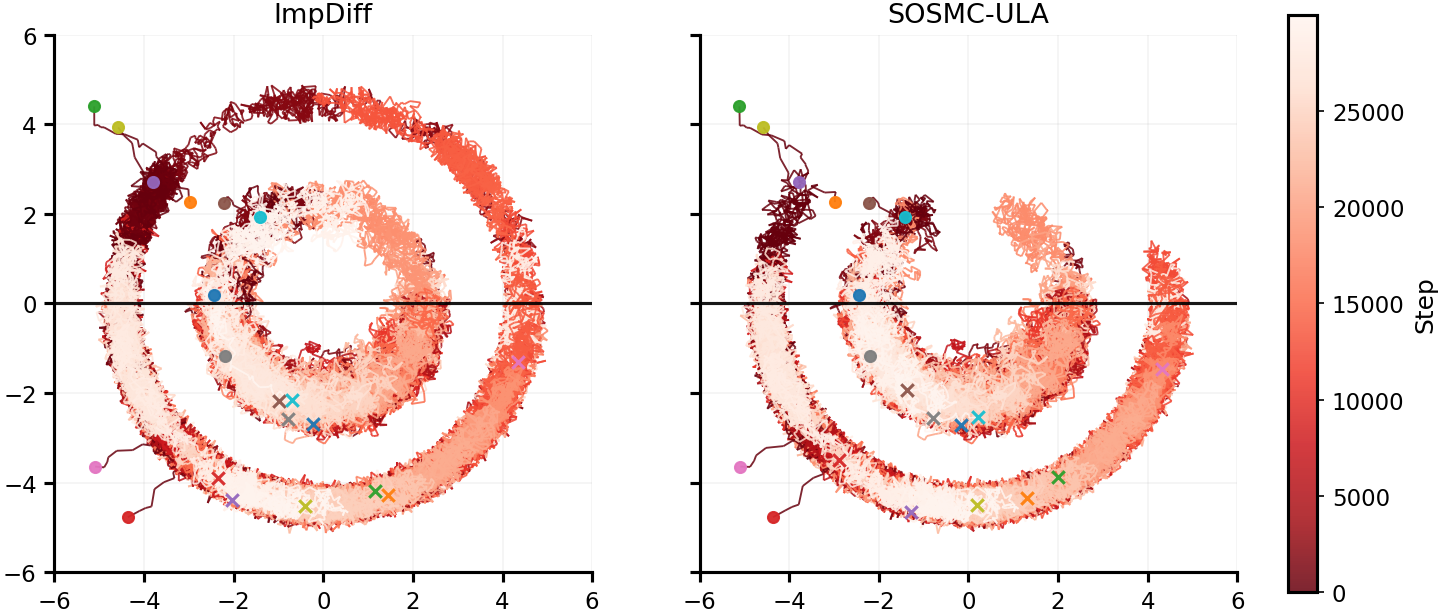

In [14]:
set_pub_style()

plot_trajectories_side_by_side(
    traj_impdiff,
    traj_sosmc,
    titles=(f"{ID_METHOD_NAME}", f"{SOSMC_METHOD_NAME}"),
    lim=6.0,
    max_particles=10,
    boundary="y0",
    step_cmap="Reds_r",
    outbase=Path("plots/particle_trajectories"),
)

Saved: plots/hitting_time_cdfs.pdf and plots/hitting_time_cdfs.png


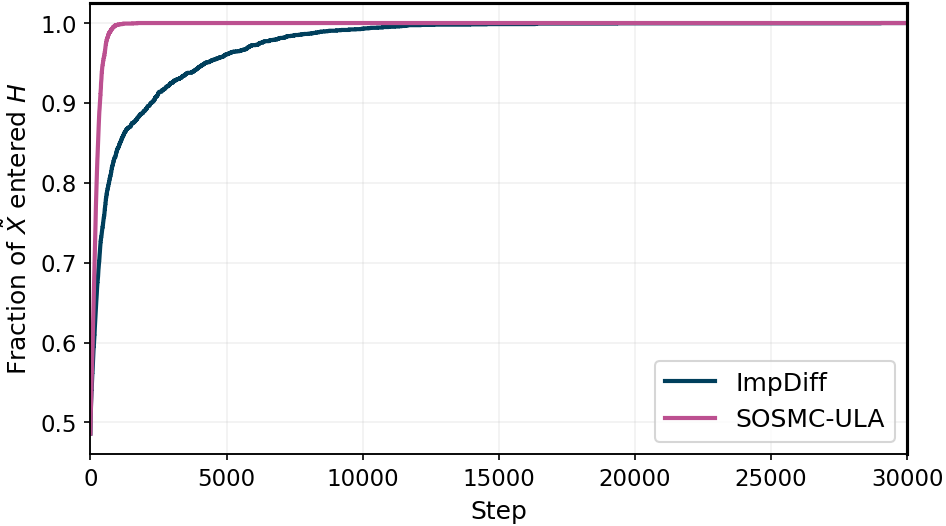

In [15]:
plot_hitting_cdf_comparison(
    [hits_impdiff, hits_sosmc],
    labels=[ID_METHOD_NAME, SOSMC_METHOD_NAME],
    T=T_track,
    title="",
    log_x=False,
    method_colors=METHOD_COLORS,
    outbase=Path("plots/hitting_time_cdfs")
)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Saved: plots/terminal_sampler_efficiency.pdf and plots/terminal_sampler_efficiency.png


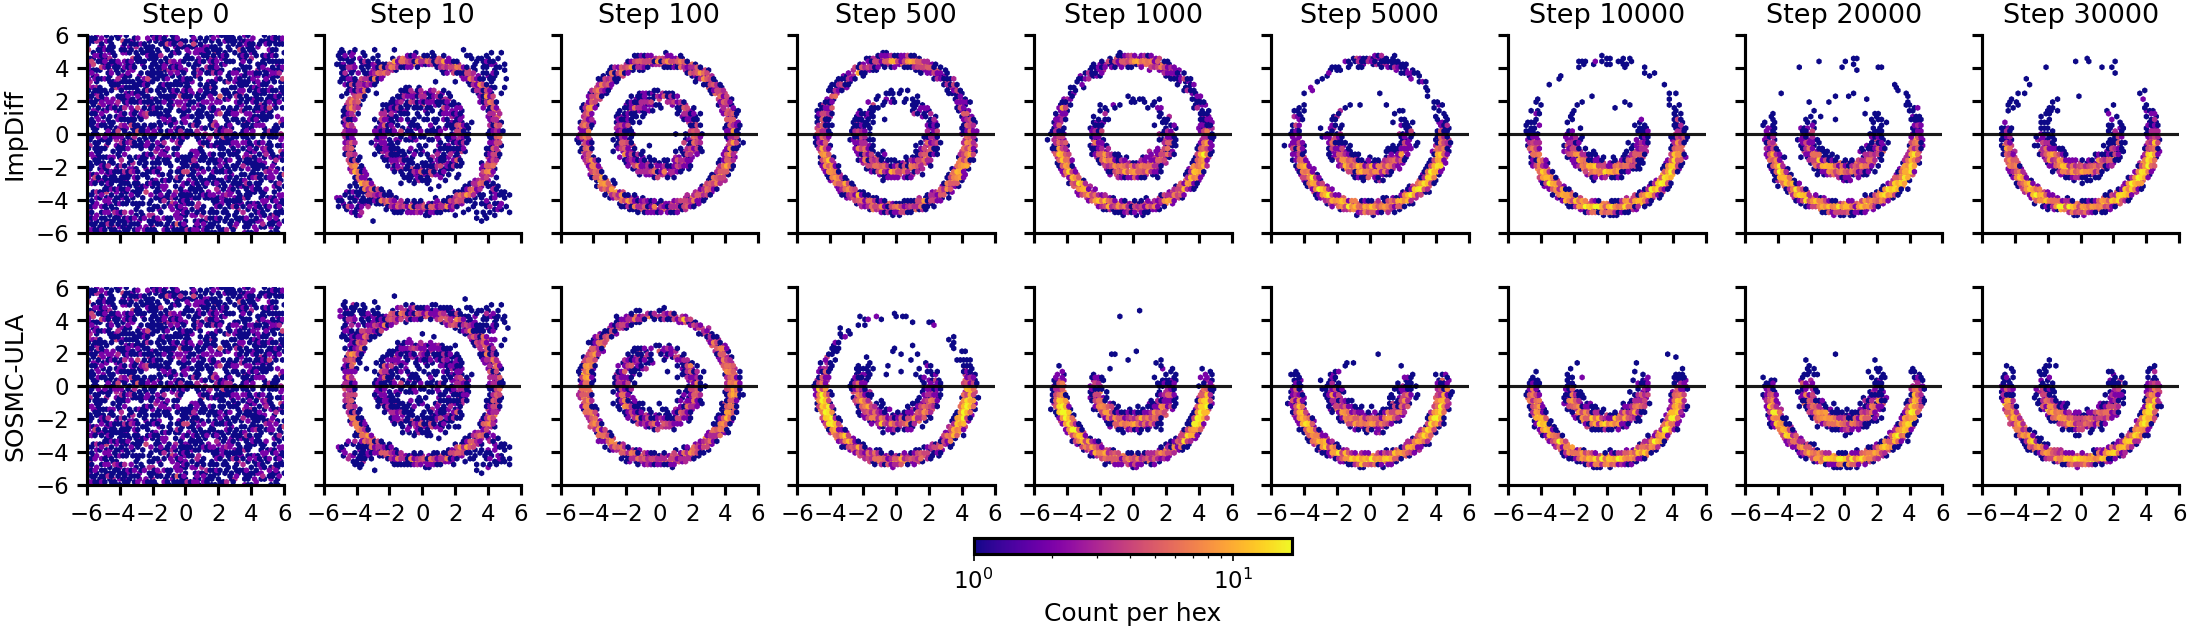

In [16]:
plot_hexbin_snapshots_comparison(
    traj_impdiff, traj_sosmc,
    steps=(0, 10, 100, 500, 1_000, 5_000, 10_000, 20_000, 30_000),
    gridsize=60,
    lim=6.0,
    boundary="y0",
    row_titles=(ID_METHOD_NAME, SOSMC_METHOD_NAME),
    add_colorbar=True,
    outbase=Path(f"plots/terminal_sampler_efficiency"),
    cmap='plasma'
)


Saved: plots/rewards_vs_steps.pdf and plots/rewards_vs_steps.png


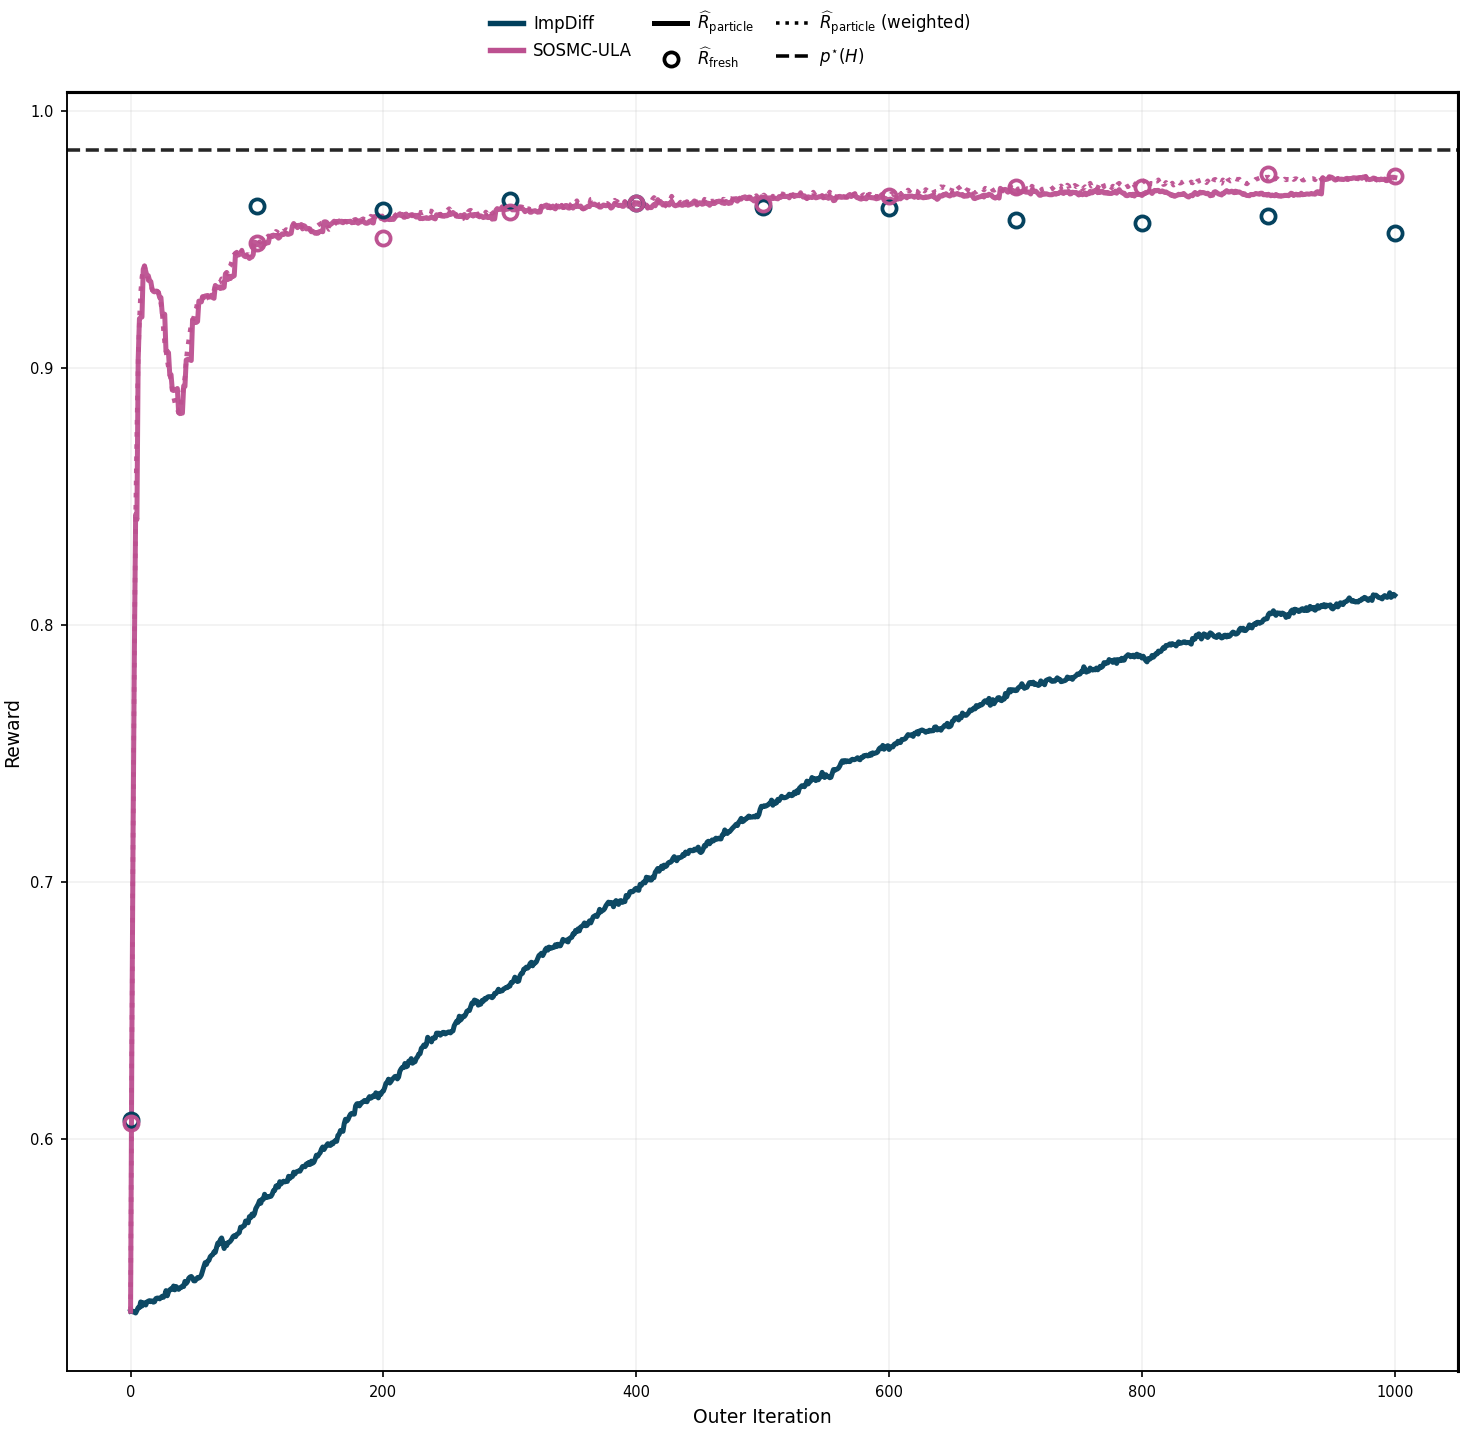

In [17]:
plot_reward_vs_steps_from_results(
    results,
    n_outer_steps=1001,
    add_zoom_panel=False,
    ylims_top=None,
    ylims_zoom=(0.9, 1),
    height_ratios=(3, 1),
    method_colors=METHOD_COLORS,
    figsize=(10, 10),
    outbase=Path("plots/rewards_vs_steps"),
)


Saved: plots/tuning_trajectories_with_objective_contours.pdf and plots/tuning_trajectories_with_objective_contours.png


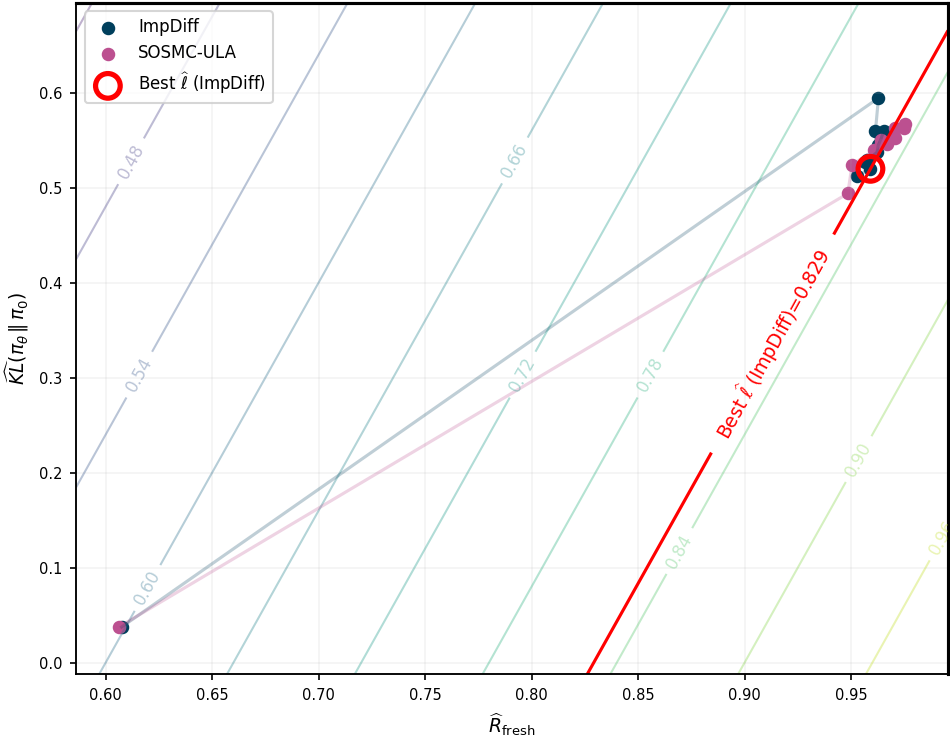

In [18]:
plot_reward_kl_with_objective_contours(
    results["history_impdiff"],
    results["history_sosmc"],
    title="",
    beta=CFG_TRIAL["beta_kl"],
    connect=True,
    method_colors=METHOD_COLORS,
    outbase=Path("plots/tuning_trajectories_with_objective_contours"),
)

## Experiment - $\beta_{KL}$ Sweep

Switch between `'eval_langevin_steps': 5_000`, ..., `'eval_burn_in': 500` and `'eval_langevin_steps': 20_000`, ..., `'eval_burn_in': 15_000` to switch between the "reduced" and "full" number of steps used to compute $\hat{R}_{\mathrm{fresh}}$.

In [ ]:
CFG_BASE = {
    'dataset_alias': 'ebm_circles',
    'checkpoint': 500,
    
    'plot_n_samples': 1,        # To reduce computation time
    'plot_langevin_steps': 1,   # To reduce computation time
    'plot_lim': 6.0,
    'plot_every': 1e8,
    'log_every': 1e8,
    
    'lr': 2e-4,
    'particle_reinit_prob': 0,
    
    'optimiser_alias': 'adam',
    'optimiser_kwargs': None,
    
    'n_particles': 10_000,
    'n_outer_steps': 5_001,
    # 'n_outer_steps': 1_001,
    'reward_fn': reward_lower_halfplane,
    
    'log_detailed_stats': False,
    'log_kl_estimates': True,
    
    'sampler_steps_per_outer': 1,
    
    # ImpDiff Specific
    'gamma_impdiff': 5e-3,
    'noise_scale_impdiff': 1.0,
    'clamp_value_impdiff': None,
    
    # sosmc Specific
    'gamma_sosmc': 5e-3,
    'gamma_sosmc_max': 1e-2,
    'gamma_sosmc_min': 1e-8,
    'adapt_factor': 1.01,
    'noise_scale_sosmc': 1.0,
    
    'ess_resample_ratio': 0.9,
    'ess_adapt_ratio': 0.95,
    
    'n_eval_fresh': 1_000,
    'eval_n_samples': 1_000,
    'eval_langevin_steps': 5_000,
    # 'eval_langevin_steps': 20_000,
    'eval_thin': 1,
    # 'eval_burn_in': 15_000,
    'eval_burn_in': 500,
    'eval_step_size': 5e-3,
    'eval_noise_scale': 1.0,
    'eval_clamp_value': None,
}

# Sweep parameters
BETA_VALUES = [0.1, 0.25, 0.5, 1.0, 5.0]
SEEDS = [0]

sweep = ExperimentSweepConfig(
    base_config=CFG_BASE,
    beta_kl_values=BETA_VALUES,
    seeds=SEEDS,
    run_impdiff=True,
    run_sosmc=True,
    # output_root="results/reward_tuning_runs_nouter_5000",
    output_root="results/reward_tuning_runs_nouter_5000_reduced_eval",
    experiment_name="beta_sweep_circles",
)

# Run (or load)...
all_results = run_sweep(sweep, save_results=True, skip_existing=True, overwrite_existing=False)

print_summary_table(all_results, BETA_VALUES)


reward_tuning_runs_nouter_5000_reduced_eval/beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b0p1_s00
True
True

[1/5] beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b0p1_s00
  -> Skipping (found existing state.pt): loading artifact...
reward_tuning_runs_nouter_5000_reduced_eval/beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b0p25_s00
True
True

[2/5] beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b0p25_s00
  -> Skipping (found existing state.pt): loading artifact...
reward_tuning_runs_nouter_5000_reduced_eval/beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b0p5_s00
True
True

[3/5] beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b0p5_s00
  -> Skipping (found existing state.pt): loading artifact...
reward_tuning_runs_nouter_5000_reduced_eval/beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b1_s00
True
True

[4/5] beta_sweep_circles_ebm_circles_adam_rlower_halfplane_g5e-3_b1_s00
  -> Skipping (found existing s

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:4968: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


Saved: plots/terminal_densities_across_betas_reduced_eval.pdf and plots/terminal_densities_across_betas_reduced_eval.png


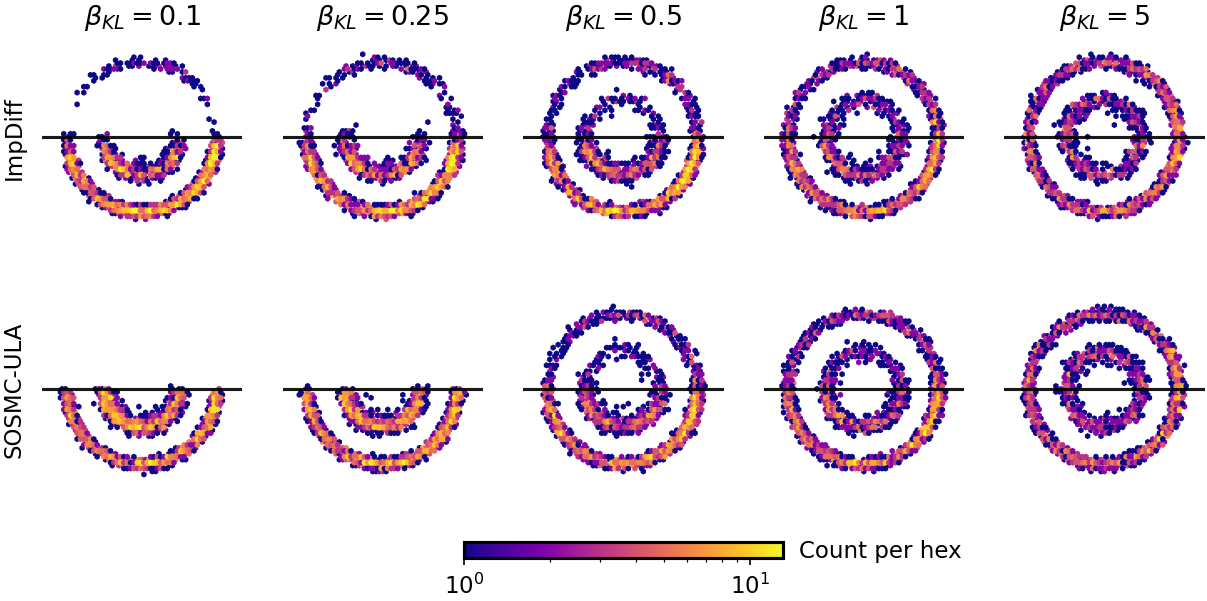

In [17]:
plot_hexbin_fresh_samples_grid_across_betas(
    sweep=sweep,
    betas=BETA_VALUES,
    seeds=SEEDS,
    out_root="results/reward_tuning_runs_nouter_5000",
    experiment_name="beta_sweep_circles",
    n_samples=2_500,
    langevin_steps=5_000,
    gridsize=60,
    lim=6.0,
    boundary="y0",
    row_titles=(ID_METHOD_NAME, SOSMC_METHOD_NAME),
    add_colorbar=True,
    # outbase=Path("plots/terminal_densities_across_betas"),
    outbase=Path("plots/terminal_densities_across_betas_reduced_eval"),
    cmap='plasma'
)


Saved: plots/tuning_trajectories_with_objective_contours_multibeta_reduced_eval.pdf and plots/tuning_trajectories_with_objective_contours_multibeta_reduced_eval.png


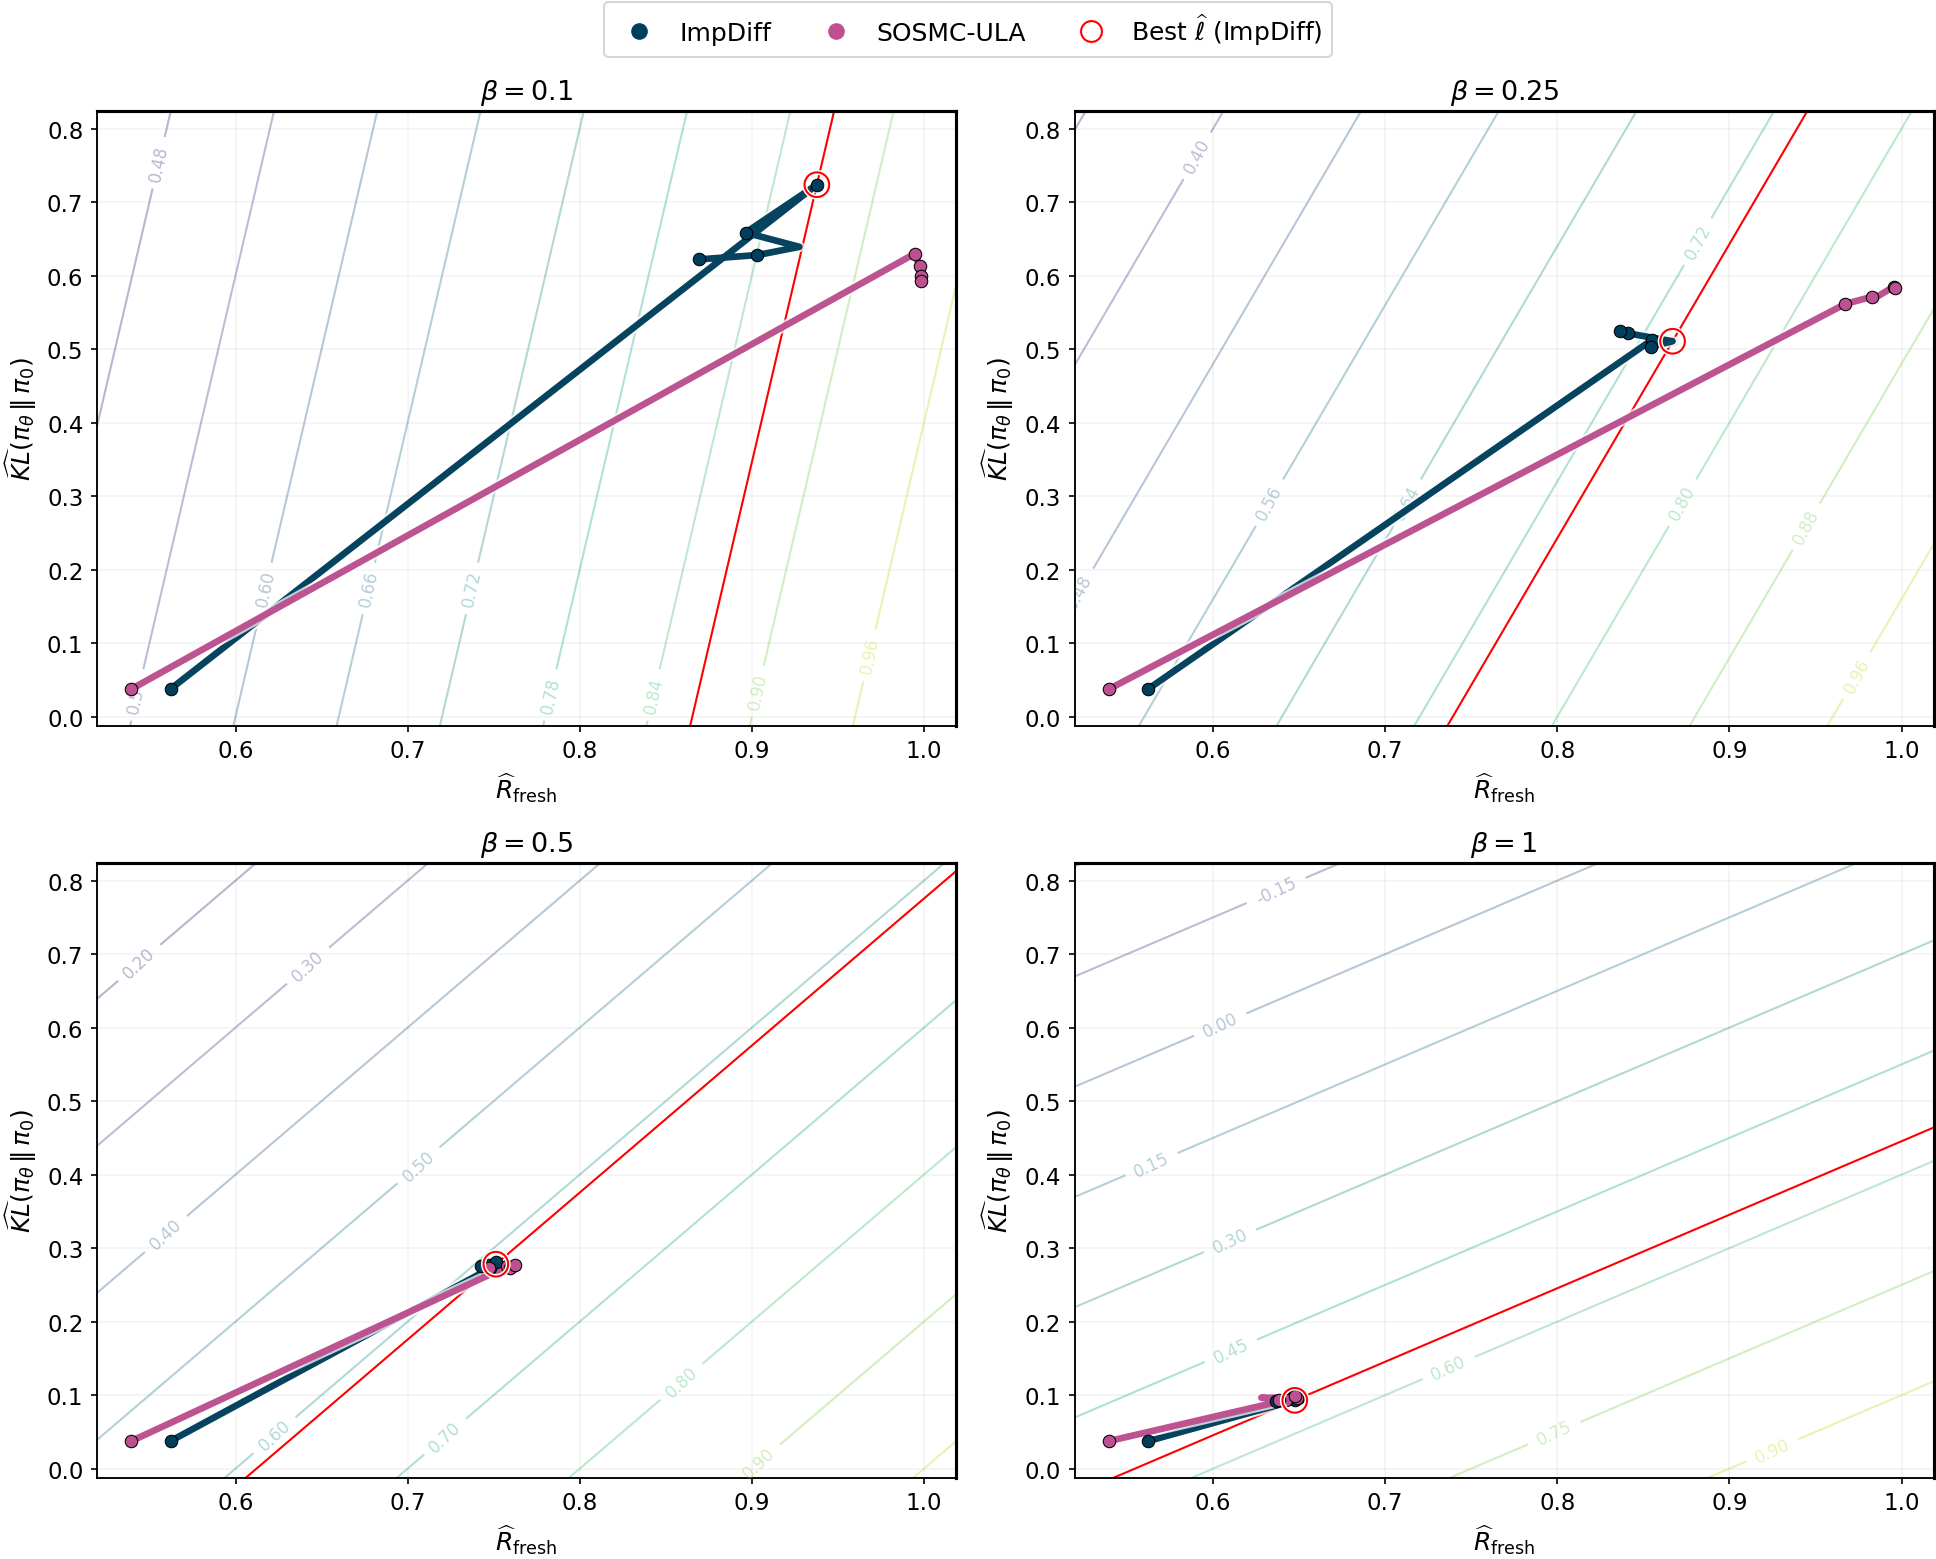

(<Figure size 1980x1560 with 4 Axes>,
 array([<Axes: title={'center': '$\\beta=0.1$'}, xlabel='$\\widehat{R}_{\\text{fresh}}$', ylabel='$\\widehat{KL}(\\pi_{\\theta} \\,\\Vert\\, \\pi_{0})$'>,
        <Axes: title={'center': '$\\beta=0.25$'}, xlabel='$\\widehat{R}_{\\text{fresh}}$', ylabel='$\\widehat{KL}(\\pi_{\\theta} \\,\\Vert\\, \\pi_{0})$'>,
        <Axes: title={'center': '$\\beta=0.5$'}, xlabel='$\\widehat{R}_{\\text{fresh}}$', ylabel='$\\widehat{KL}(\\pi_{\\theta} \\,\\Vert\\, \\pi_{0})$'>,
        <Axes: title={'center': '$\\beta=1$'}, xlabel='$\\widehat{R}_{\\text{fresh}}$', ylabel='$\\widehat{KL}(\\pi_{\\theta} \\,\\Vert\\, \\pi_{0})$'>],
       dtype=object))

In [18]:
plot_reward_kl_objective_panels(
    all_results,
    beta_values=BETA_VALUES[:-1],
    method_colors=METHOD_COLORS,
    # outbase=Path("plots/tuning_trajectories_with_objective_contours_multibeta"),
    outbase=Path("plots/tuning_trajectories_with_objective_contours_multibeta_reduced_eval"),
    milestone_markers=5,
    best_ring_lw=1.0
)
